# LFP coherence over distance (DIV 12) - wavelet coherence

Coherence-over-distance analysis after Gireesh & Plenz (2008), on HD-MEA LFP.

**Why wavelet coherence (not Hilbert PLV).** Coherence between two signals at a single
resolved time-frequency point is identically 1; a meaningful estimate requires averaging the
cross-spectrum over a time-frequency neighbourhood and normalising by power. A Hilbert
phase-locking value over a short window has *no* such smoothing and discards amplitude, so at
low frequency (few cycles per window) it saturates near 1 and shows no burst-vs-background
contrast. This notebook uses the **smoothed Morlet wavelet coherence** the paper used:
`|S(Wx Wy*)| / sqrt(S(|Wx|^2) S(|Wy|^2))` with Gaussian smoothing `S` over frequency bins and
time.

**Pipeline**
1. **Burst detection** - figure-2 spike pipeline (consistent with figure 2).
2. **Snap to LFP peak** - each spike anchor is snapped to the nearest population-LFP envelope
   peak inside the burst; the snap offset distribution is reported.
3. **Windows (decoupled)** - the Morlet transform runs on a generously padded segment
   (`WAVELET_PAD_S` each side) so coherence is free of edge/COI artefacts; coherence is then
   *averaged* only over a narrow fixed window around the snapped peak (`COH_AVG_HALF_MS`),
   independent of burst duration.
4. **Diagnostics** - per-event mean-LFP trace + Morlet power spectrogram + wavelet
   coherence-to-reference spectrogram (reference = largest-nLFP electrode).
5. **Coherence over distance** - per band, smoothed wavelet coherence between the reference and
   target channels grouped by inter-electrode distance, normalised against time-shifted
   background windows.
6. **nLFP-magnitude ranking** - fig-2 detection is permissive, so bursts are ranked by their
   population nLFP magnitude. Example spectrograms show the strongest bursts first, and the
   coherence-over-distance is recomputed over the top-n strongest events for a sweep of n - so we
   can see the effect emerge as weak/noise "bursts" are dropped.

In [120]:
%matplotlib inline

from __future__ import annotations

from pathlib import Path
import os
import pickle
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter, gaussian_filter1d, uniform_filter1d
from scipy.signal import fftconvolve

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax.metrics.burst import (
    assign_max_population_ifr_burst_anchors,
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
)
from ephax.metrics.lfp import (
    bandpass_downsample,
    dataset_for_well,
    extract_phasors,
    inspect_file,
    load_chunk,
    load_data_store_spikes,
)
from ephax.preprocessing.dataset import Recording
from ephax.plotting import PAPER_COLORS, apply_paper_style

apply_paper_style()
plt.rcParams["figure.dpi"] = 150
np.random.seed(0)

## Parameters

In [ ]:
DIV = 23
WELLS = [0, 1, 2, 3, 4, 5]
EXAMPLE_WELL = 0
TOP_START = 0
TOP_STOP = 100
MIN_AMP = 0.0

# --- Figure 2 burst detection ---
IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0

# --- LFP loading / Morlet wavelet ---
COHERENCE_FS_HZ = 500.0
COHERENCE_FILTER_LOW_HZ = 4.0
COHERENCE_FILTER_HIGH_HZ = 120.0
WAVELET_LOW_HZ = 4.0
WAVELET_HIGH_HZ = 100.0
SUBOCTAVES = 12
MORLET_N_CYCLES = 7.0
LINE_NOISE_EXCLUSION_HZ = (58.0, 62.0)
# Scale-dependent (Torrence-Compo style) coherence smoothing: time-smooth per frequency with
# sigma = N_PERIODS / f, then smooth across SCALE_BINS suboctave bins. Enough smoothing gives the
# estimator real degrees of freedom (low coherence for incoherent signals); too little biases it to 1.
WAVELET_SMOOTH_N_PERIODS = 2.0
WAVELET_SMOOTH_SCALE_BINS = 2.0
WAVELET_PAD_S = 0.60   # CWT support / COI padding each side of the averaging window (clean coherence)

FREQUENCY_BANDS = {"theta": (4.0, 8.0), "beta": (12.0, 30.0), "gamma": (30.0, 50.0)}

# --- Snap spike anchor -> population LFP envelope peak ---
SNAP_SMOOTH_MS = 6.0
SNAP_SEARCH_PRE_MS = 60.0
SNAP_SEARCH_POST_MS = 60.0

# --- Coherence averaging window: how wide around the snapped peak we average coherence ---
# Decoupled from burst duration AND from the CWT padding above. This is the knob to sweep.
COH_AVG_HALF_MS = 40.0

# --- Distance binning ---
MIN_DISTANCE_UM = 50.0
MAX_DISTANCE_UM = 3500.0
DISTANCE_BIN_UM = 100.0

# --- Event selection: rank fig-2 bursts by population nLFP magnitude, keep the strongest ---
MAX_EVENTS_PER_WELL = int(os.environ.get("LFP_COH_MAX_EVENTS_PER_WELL", "50"))  # top-N by nLFP computed per well
TOP_N_SWEEP = [5, 10, 25, 50]   # averaged coherence over the top-n strongest bursts (post-hoc; not in cache key)
SHIFT_REPS = int(os.environ.get("LFP_COH_SHIFT_REPS", "3"))
BACKGROUND_SHIFT_MAX_S = 3.0
BACKGROUND_TRIES = 200
BOOTSTRAP_REPS = int(os.environ.get("LFP_COH_BOOTSTRAP_REPS", "1000"))
RANDOM_SEED = 0

# --- Spectrogram diagnostic ---
SPECTROGRAM_N_EVENTS = int(os.environ.get("LFP_COH_SPECTROGRAM_EVENTS", "10"))
SPECTROGRAM_N_ELECTRODES = int(os.environ.get("LFP_COH_SPECTROGRAM_ELECTRODES", "12"))
SPECTROGRAM_PAD_S = 0.25

# --- Rank-stratified burst-aligned power spectrograms (separate, power-only pass) ---
POWERSPEC_T_DISP = 0.30          # display half-window around the anchor
POWERSPEC_PAD = WAVELET_PAD_S    # extra Morlet/COI padding (clean low-freq power)
RANK_STRATA = [(1, 5), (6, 15), (16, 30), (31, 50)]  # disjoint nLFP-rank bins
IFR_PEAK_HZ = 37.76              # population IFR peak frequency for this DIV (reference line)
POWERSPEC_PEAK_MS = 20.0         # peri-anchor window for the 1/f-corrected power spectrum

# --- Spike-field phase locking (per Morlet suboctave) ---
SF_MIN_SPIKES = 25               # min spikes per electrode to include in the PPC average
SF_SHUFFLE = True                # sample-shuffled null
SPIKE_REMOVE_MS = 2.0            # raw LFP blanked/interpolated +-this around each spike (spike-removed metric)
SF_BLEED_EXCLUDE_UM = 50.0       # distance-resolved: drop pairs closer than this (residual spike bleed in neighbours)
SF_PHASE_BINS = 36               # circular histogram bins for spike-phase distributions (figure-3 style Rayleigh)

FORCE_RECOMPUTE = False
SAVE_TABLES = True


def morlet_frequencies(low_hz=WAVELET_LOW_HZ, high_hz=WAVELET_HIGH_HZ, suboctaves=SUBOCTAVES):
    exponents = np.arange(np.log2(float(low_hz)), np.log2(float(high_hz)) + 1e-9, 1.0 / int(suboctaves))
    freqs = 2.0 ** exponents
    return freqs[freqs <= float(high_hz) * (1.0 + 1e-9)]


WAVELET_FREQS_HZ = morlet_frequencies()
print(f"Morlet frequencies: {len(WAVELET_FREQS_HZ)} bins, {WAVELET_FREQS_HZ[0]:.2f}-{WAVELET_FREQS_HZ[-1]:.2f} Hz")

Morlet frequencies: 56 bins, 4.00-95.89 Hz


In [122]:
RAW_LFP_FILE = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull") / f"DIV {DIV}" / "data.raw.h5"
SMOKE_MODE = os.environ.get("LFP_COH_SMOKE", "0") == "1"
OUTPUT_DIR = repo_root / "outputs" / "lfp_coherence_distance_div12_wavelet_snapped_anchor"
if SMOKE_MODE:
    OUTPUT_DIR = OUTPUT_DIR / "smoke"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
CACHE_PATH = OUTPUT_DIR / "wavelet_coherence_distance_cache.pkl"
POWERSPEC_CACHE_PATH = OUTPUT_DIR / "stratified_power_spectrograms_cache.pkl"
SPIKEFIELD_CACHE_PATH = OUTPUT_DIR / "spike_field_locking_cache.pkl"
for _path in (OUTPUT_DIR, TABLE_DIR, FIGURE_DIR):
    _path.mkdir(parents=True, exist_ok=True)

if SMOKE_MODE:
    WELLS = [EXAMPLE_WELL]
    MAX_EVENTS_PER_WELL = min(MAX_EVENTS_PER_WELL, 8)
    TOP_N_SWEEP = [3, 8]
    SHIFT_REPS = min(SHIFT_REPS, 1)
    BOOTSTRAP_REPS = min(BOOTSTRAP_REPS, 50)
    SPECTROGRAM_N_EVENTS = min(SPECTROGRAM_N_EVENTS, 3)

TOP_N_SWEEP = sorted({min(int(n), MAX_EVENTS_PER_WELL) for n in TOP_N_SWEEP})
RANK_STRATA = [(lo, min(hi, MAX_EVENTS_PER_WELL)) for lo, hi in RANK_STRATA if lo <= MAX_EVENTS_PER_WELL]

# CONFIG keys cache validity. TOP_N_SWEEP is a post-hoc summary knob, so it is deliberately
# excluded - changing the sweep re-runs only the summaries, reusing the per-event cache.
CONFIG = {
    "div": DIV, "wells": WELLS, "top_start": TOP_START, "top_stop": TOP_STOP,
    "coherence_fs_hz": COHERENCE_FS_HZ, "wavelet_range_hz": (WAVELET_LOW_HZ, WAVELET_HIGH_HZ),
    "morlet_n_cycles": MORLET_N_CYCLES, "suboctaves": SUBOCTAVES,
    "tf_smooth_scaledep": (WAVELET_SMOOTH_N_PERIODS, WAVELET_SMOOTH_SCALE_BINS),
    "bands": FREQUENCY_BANDS, "n_max_events_per_well": MAX_EVENTS_PER_WELL, "shift_reps": SHIFT_REPS,
    "anchor_method": "fig2_spike_ifr_snapped_to_lfp_envelope_peak",
    "event_selection": "top_n_by_population_nlfp_magnitude",
    "window_method": "fixed_peak_window", "coh_avg_half_ms": COH_AVG_HALF_MS, "wavelet_pad_s": WAVELET_PAD_S,
    "coherence_estimator": "scaledep_smoothed_morlet_pairwise_mean_coherence_per_distance_bin",
    "reference": "largest_nlfp_electrode",
}
CONFIG

{'div': 12,
 'wells': [0, 1, 2, 3, 4, 5],
 'top_start': 0,
 'top_stop': 100,
 'coherence_fs_hz': 500.0,
 'wavelet_range_hz': (4.0, 100.0),
 'morlet_n_cycles': 7.0,
 'suboctaves': 12,
 'tf_smooth_scaledep': (2.0, 2.0),
 'bands': {'theta': (4.0, 8.0), 'beta': (12.0, 30.0), 'gamma': (30.0, 50.0)},
 'n_max_events_per_well': 50,
 'shift_reps': 3,
 'anchor_method': 'fig2_spike_ifr_snapped_to_lfp_envelope_peak',
 'event_selection': 'top_n_by_population_nlfp_magnitude',
 'window_method': 'fixed_peak_window',
 'coh_avg_half_ms': 40.0,
 'wavelet_pad_s': 0.6,
 'coherence_estimator': 'scaledep_smoothed_morlet_pairwise_mean_coherence_per_distance_bin',
 'reference': 'largest_nlfp_electrode'}

## Step 1 - Figure 2 burst detection

In [123]:
def _recording_for_well(well):
    dataset = dataset_for_well(well)
    info = inspect_file(RAW_LFP_FILE, dataset)
    spikes, layout, sf = load_data_store_spikes(RAW_LFP_FILE, dataset, min_amp=MIN_AMP)
    raw_stop_s = float(info["raw_shape"][1]) / float(info["fs_raw"])
    spike_stop_s = float(np.nanmax(spikes["time"])) if len(spikes.get("time", [])) else raw_stop_s
    stop_s = min(raw_stop_s, spike_stop_s)
    recording = Recording(spikes=spikes, layout=layout, start_time=0.0, end_time=stop_s, sf=float(sf))
    return recording, info


def detect_well_burst_anchors(well):
    recording, info = _recording_for_well(well)
    refs = recording.refs_top(start=TOP_START, stop=TOP_STOP)
    population = build_population_ifr(recording, refs, grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC)
    high_epochs, _ = detect_high_activity_epochs(
        population.time_grid, population.mean_ifr_smooth,
        mad_scale=HIGH_ACTIVITY_MAD_SCALE, min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS, max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    )
    highres = build_highres_traces(recording, refs, bin_ms=HIGHRES_BIN_MS, smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS)
    participation = build_participation_activity_state(highres, aggregation_ms=NETWORK_BIN_MS)
    bursts = detect_participation_burst_epochs(
        participation, high_epochs,
        min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION, min_duration_ms=NETWORK_MIN_DURATION_MS,
    )
    bursts = assign_max_population_ifr_burst_anchors(highres, bursts).sort_values("anchor_time_s").reset_index(drop=True)
    bursts.insert(0, "well", int(well))
    bursts.insert(1, "dataset", dataset_for_well(well))
    return {
        "well": int(well), "info": info, "refs": np.asarray(refs, dtype=int),
        "population": population, "high_epochs": high_epochs, "bursts": bursts,
    }


def build_anchor_contexts(wells=WELLS):
    contexts = {}
    for well in wells:
        t0 = perf_counter()
        contexts[int(well)] = detect_well_burst_anchors(int(well))
        print(f"well {well}: refs={len(contexts[int(well)]['refs'])}, bursts={len(contexts[int(well)]['bursts'])}, elapsed={perf_counter() - t0:.1f}s")
    return contexts


anchor_contexts = build_anchor_contexts(WELLS)

well 0: refs=100, bursts=531, elapsed=2.3s
well 1: refs=100, bursts=390, elapsed=1.7s
well 2: refs=100, bursts=727, elapsed=2.3s
well 3: refs=100, bursts=513, elapsed=2.0s
well 4: refs=100, bursts=525, elapsed=1.9s
well 5: refs=100, bursts=358, elapsed=1.7s


## Step 2 - LFP loaders and Morlet wavelet coherence

`_load_lfp_segment` reads the selected channels, band-passes (4-120 Hz) and downsamples to 500 Hz.
`morlet_coefficients` gives the complex CWT. Coherence is computed **per electrode pair** and the
magnitudes are averaged across targets (`pairwise_coherence_maps`) - NOT by complex-averaging the
cross-spectrum across targets first, which cancels under constant phase lags (propagation /
position-dependent phase) and collapses coherence even for perfectly coherent, lagged sites.

In [124]:
def distance_edges_and_centers():
    edges = np.arange(MIN_DISTANCE_UM, MAX_DISTANCE_UM + DISTANCE_BIN_UM, DISTANCE_BIN_UM, dtype=float)
    if edges[-1] < MAX_DISTANCE_UM:
        edges = np.append(edges, MAX_DISTANCE_UM)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return edges, centers


def _mapping_for_recording(dataset):
    _, _, _, mapping = load_chunk(RAW_LFP_FILE, dataset, 0, 1)
    return pd.DataFrame({
        "channel": np.asarray(mapping["channel"], dtype=int),
        "electrode": np.asarray(mapping["electrode"], dtype=int),
        "x_um": np.asarray(mapping["x"], dtype=float),
        "y_um": np.asarray(mapping["y"], dtype=float),
    })


def _channels_for_electrodes(dataset, electrodes):
    frame = _mapping_for_recording(dataset)
    requested = pd.DataFrame({"electrode": np.asarray(electrodes, dtype=int)})
    return requested.merge(frame, on="electrode", how="inner").drop_duplicates("electrode").reset_index(drop=True)


def load_lfp_segment(dataset, center_s, window_s, electrodes, *, min_channels=2):
    info = inspect_file(RAW_LFP_FILE, dataset)
    fs_raw = float(info["fs_raw"])
    recording_stop_s = float(info["raw_shape"][1]) / fs_raw
    half = 0.5 * float(window_s)
    start_s, stop_s = float(center_s) - half, float(center_s) + half
    if start_s < 0 or stop_s > recording_stop_s:
        return None
    channel_table = _channels_for_electrodes(dataset, electrodes)
    if len(channel_table) < int(min_channels):
        return None
    start_frame = int(round(start_s * fs_raw))
    n_frames = max(1, int(round((stop_s - start_s) * fs_raw)))
    raw, _, fs_loaded, mapping = load_chunk(RAW_LFP_FILE, dataset, start_frame, n_frames, channels=channel_table["channel"].to_numpy(int))
    if raw.shape[0] < 8 or raw.shape[1] < int(min_channels):
        return None
    band = bandpass_downsample(raw, fs_loaded, COHERENCE_FILTER_LOW_HZ, COHERENCE_FILTER_HIGH_HZ, COHERENCE_FS_HZ, max_channels_per_block=128)
    coords_um = np.column_stack([np.asarray(mapping["x"], dtype=float), np.asarray(mapping["y"], dtype=float)])
    t_s = start_s + np.arange(band.shape[0], dtype=float) / float(COHERENCE_FS_HZ)
    return {
        "data": band.astype(np.float32, copy=False), "t_s": t_s, "coords_um": coords_um,
        "electrodes": np.asarray(mapping["electrode"], dtype=int), "start_s": start_s, "stop_s": stop_s,
        "center_s": float(center_s), "window_s": float(window_s),
    }


def morlet_coefficients(traces, fs_hz=COHERENCE_FS_HZ, freqs_hz=None, *, n_cycles=MORLET_N_CYCLES):
    freqs_hz = WAVELET_FREQS_HZ if freqs_hz is None else freqs_hz
    x = np.asarray(traces, dtype=np.float32)
    if x.ndim != 2:
        raise ValueError("traces must be samples x channels")
    x = np.nan_to_num(x - np.nanmean(x, axis=0, keepdims=True), copy=False)
    coeffs = np.empty((len(freqs_hz), x.shape[0], x.shape[1]), dtype=np.complex64)
    for fi, freq_hz in enumerate(np.asarray(freqs_hz, dtype=float)):
        sigma_t = float(n_cycles) / (2.0 * np.pi * float(freq_hz))
        half_width = max(3, int(np.ceil(4.0 * sigma_t * float(fs_hz))))
        tau = np.arange(-half_width, half_width + 1, dtype=float) / float(fs_hz)
        wavelet = np.exp(2j * np.pi * float(freq_hz) * tau) * np.exp(-(tau ** 2) / (2.0 * sigma_t ** 2))
        wavelet /= np.sqrt(np.sum(np.abs(wavelet) ** 2))
        coeffs[fi] = fftconvolve(x, np.conj(wavelet[::-1, None]), mode="same", axes=0).astype(np.complex64, copy=False)
    return coeffs


def largest_nlfp_reference(data):
    negative_peak = -np.nanmin(np.asarray(data, dtype=float), axis=0)
    if not np.any(np.isfinite(negative_peak)):
        return None
    return int(np.nanargmax(negative_peak))


def _band_frequency_mask(band):
    low, high = map(float, band)
    mask = (WAVELET_FREQS_HZ >= low) & (WAVELET_FREQS_HZ <= high)
    if LINE_NOISE_EXCLUSION_HZ is not None:
        nlo, nhi = map(float, LINE_NOISE_EXCLUSION_HZ)
        mask &= ~((WAVELET_FREQS_HZ >= nlo) & (WAVELET_FREQS_HZ <= nhi))
    return mask


def _peak_frequency_from_power(coeffs, band, time_mask):
    freq_idx = np.flatnonzero(_band_frequency_mask(band))
    if freq_idx.size == 0 or not np.any(time_mask):
        return np.nan
    power = np.nanmean(np.abs(coeffs[freq_idx][:, time_mask, :]) ** 2, axis=(1, 2))
    if not np.any(np.isfinite(power)):
        return np.nan
    return float(WAVELET_FREQS_HZ[int(freq_idx[int(np.nanargmax(power))])])


def _smooth_tf(arr):
    # Scale-dependent smoothing of a (F, T) or (F, T, J) real array: time-smooth each
    # frequency row with sigma = N_PERIODS / f samples, then smooth across scale (freq) bins.
    out = np.empty(arr.shape, dtype=float)
    for i, freq_hz in enumerate(WAVELET_FREQS_HZ):
        sig_t = max(0.5, (float(WAVELET_SMOOTH_N_PERIODS) / float(freq_hz)) * float(COHERENCE_FS_HZ))
        out[i] = gaussian_filter1d(arr[i], sigma=sig_t, axis=0, mode="nearest")
    if float(WAVELET_SMOOTH_SCALE_BINS) > 0:
        out = gaussian_filter1d(out, sigma=float(WAVELET_SMOOTH_SCALE_BINS), axis=0, mode="nearest")
    return out


def pairwise_coherence_maps(coeffs, ref_idx, target_coeffs, target_idx):
    # Per-pair smoothed wavelet coherence maps, shape (freq, time, n_targets).
    # Each target's coherence to the reference is normalised BEFORE averaging across
    # targets, so constant phase lags (propagation / position-dependent phase) do not
    # cancel - unlike a complex average of the cross-spectrum, which collapses under
    # phase dispersion even for perfectly coherent, lagged sites.
    ref = coeffs[:, :, int(ref_idx)]                      # (F, T)
    tgt = target_coeffs[:, :, target_idx]                 # (F, T, J)
    cross = ref[:, :, None] * np.conj(tgt)                # (F, T, J)
    smooth_cross = _smooth_tf(cross.real) + 1j * _smooth_tf(cross.imag)
    smooth_ref = _smooth_tf(np.abs(ref) ** 2)[:, :, None]
    smooth_tgt = _smooth_tf(np.abs(tgt) ** 2)
    denom = np.sqrt(np.maximum(smooth_ref * smooth_tgt, np.finfo(float).tiny))
    return np.clip(np.abs(smooth_cross) / denom, 0.0, 1.0)


def wavelet_coherence_time_frequency(coeffs, ref_idx, target_coeffs=None, target_idx=None):
    # Mean pairwise wavelet coherence map (freq, time) of the reference to its targets.
    coeffs = np.asarray(coeffs)
    target_coeffs = coeffs if target_coeffs is None else np.asarray(target_coeffs)
    ref_idx = int(ref_idx)
    if target_idx is None:
        target_idx = np.flatnonzero(np.arange(coeffs.shape[2]) != ref_idx)
    else:
        target_idx = np.asarray(target_idx, dtype=int)
    target_idx = target_idx[target_idx != ref_idx]
    if target_idx.size == 0:
        return np.full(coeffs.shape[:2], np.nan, dtype=float)
    return np.nanmean(pairwise_coherence_maps(coeffs, ref_idx, target_coeffs, target_idx), axis=2)


def average_tf_coherence_map(tf_coh, freq_mask, time_mask):
    freq_idx = np.flatnonzero(freq_mask)
    time_idx = np.flatnonzero(time_mask)
    if freq_idx.size == 0 or time_idx.size < 3:
        return np.nan
    return float(np.nanmean(tf_coh[freq_idx][:, time_idx]))

## Step 3 - Snap spike anchor to the population-LFP envelope peak

The spike-IFR anchor is snapped to the nearest peak of the mean LFP analytic-amplitude envelope
(across the selected channels) within `+/-SNAP_SEARCH_*_MS`, clamped to the burst. This is the
local analogue of the paper's "time of maximal summed nLFP".

In [125]:
_SNAP_NULL = {"lfp_anchor_time_s": np.nan, "anchor_offset_ms": 0.0, "snap_valid": False, "nlfp_magnitude_uv": 0.0, "lfp_envelope_peak_uv": 0.0}


def snap_anchor_to_lfp_peak(dataset, refs, spike_anchor_s, burst_start_s, burst_stop_s):
    duration_s = float(burst_stop_s) - float(burst_start_s)
    center = 0.5 * (float(burst_start_s) + float(burst_stop_s))
    segment = load_lfp_segment(dataset, center, duration_s + 2.0 * SNAP_SEARCH_PRE_MS / 1000.0 + 0.10, refs, min_channels=1)
    if segment is None:
        return {**_SNAP_NULL, "lfp_anchor_time_s": float(spike_anchor_s)}
    _, amp = extract_phasors(segment["data"])
    pop = np.nanmean(amp, axis=1)
    smooth_n = max(1, int(round(SNAP_SMOOTH_MS * COHERENCE_FS_HZ / 1000.0)))
    if smooth_n > 1:
        pop = uniform_filter1d(pop, size=smooth_n, mode="nearest")
    mean_lfp = np.nanmean(segment["data"], axis=1)  # population LFP trace (across selected channels)
    t_ds = segment["t_s"]
    lo = max(float(burst_start_s), float(spike_anchor_s) - SNAP_SEARCH_PRE_MS / 1000.0)
    hi = min(float(burst_stop_s), float(spike_anchor_s) + SNAP_SEARCH_POST_MS / 1000.0)
    mask = (t_ds >= lo) & (t_ds <= hi) & np.isfinite(pop)
    if not np.any(mask):
        return {**_SNAP_NULL, "lfp_anchor_time_s": float(spike_anchor_s)}
    idx = np.flatnonzero(mask)
    peak = int(idx[np.nanargmax(pop[idx])])
    lfp_anchor = float(t_ds[peak])
    # Population nLFP magnitude: depth of the negative population deflection inside the burst (uV).
    nlfp_magnitude_uv = float(-np.nanmin(mean_lfp[mask]) * 1e6)
    return {
        "lfp_anchor_time_s": lfp_anchor,
        "anchor_offset_ms": (lfp_anchor - float(spike_anchor_s)) * 1000.0,
        "snap_valid": True,
        "nlfp_magnitude_uv": nlfp_magnitude_uv,
        "lfp_envelope_peak_uv": float(pop[peak] * 1e6),
    }


def add_snapped_anchors(contexts):
    for well, ctx in contexts.items():
        bursts = ctx["bursts"]
        dataset = dataset_for_well(int(well))
        records = [
            snap_anchor_to_lfp_peak(dataset, ctx["refs"], float(r.anchor_time_s), float(r.start_time_s), float(r.end_time_s))
            for r in bursts.itertuples(index=False)
        ]
        snap = pd.DataFrame(records, index=bursts.index)
        for col in ("lfp_anchor_time_s", "anchor_offset_ms", "snap_valid", "nlfp_magnitude_uv", "lfp_envelope_peak_uv"):
            bursts[col] = snap[col].to_numpy()
        bursts["nlfp_rank"] = bursts["nlfp_magnitude_uv"].rank(ascending=False, method="first").astype(int)
        ctx["bursts"] = bursts
    return contexts


anchor_contexts = add_snapped_anchors(anchor_contexts)
anchor_table = pd.concat([ctx["bursts"] for ctx in anchor_contexts.values()], ignore_index=True)
anchor_table["lfp_anchor_inside_burst"] = (
    (anchor_table["lfp_anchor_time_s"] >= anchor_table["start_time_s"]) & (anchor_table["lfp_anchor_time_s"] <= anchor_table["end_time_s"])
)
assert bool(anchor_table["lfp_anchor_inside_burst"].all()), "A snapped LFP anchor falls outside its burst."
print(anchor_table.sort_values("nlfp_magnitude_uv", ascending=False)[["well", "event_idx", "lfp_anchor_time_s", "anchor_offset_ms", "nlfp_magnitude_uv", "nlfp_rank", "duration_ms"]].head().to_string(index=False))
anchor_table.head()

 well  event_idx  lfp_anchor_time_s  anchor_offset_ms  nlfp_magnitude_uv  nlfp_rank  duration_ms
    3        178            197.886               1.5          20.373240          1        100.0
    3        361            417.844               1.5          19.683070          2        100.0
    0        232            258.070              38.5          18.519928          1        270.0
    3        425            519.632              -0.5          18.388389          3         90.0
    3        233            257.852               2.5          18.315699          4         60.0


,well,dataset,event_idx,high_activity_event_idx,start_idx,end_idx,start_time_s,end_time_s,coarse_peak_idx,coarse_peak_time_s,...,participation_anchor_time_s,anchor_method,anchor_population_rate_hz,lfp_anchor_time_s,anchor_offset_ms,snap_valid,nlfp_magnitude_uv,lfp_envelope_peak_uv,nlfp_rank,lfp_anchor_inside_burst
0,0,data0000,0,0,1591,1616,15.91,16.17,16114,16.1145,...,16.115,max_highres_population_ifr,43.407215,16.160,45.5,True,18.246723,27.137929,2,True
1,0,data0000,1,0,1628,1633,16.28,16.34,16329,16.3295,...,16.305,max_highres_population_ifr,9.928201,16.300,-29.5,True,3.437956,18.124687,55,True
2,0,data0000,2,0,1639,1666,16.39,16.67,16590,16.5905,...,16.405,max_highres_population_ifr,20.273344,16.558,-32.5,True,2.865496,14.597992,80,True
3,0,data0000,3,0,1669,1676,16.69,16.77,16718,16.7185,...,16.715,max_highres_population_ifr,7.545081,16.748,29.5,True,2.626712,14.307187,99,True
4,0,data0000,4,0,1686,1692,16.86,16.93,16900,16.9005,...,16.905,max_highres_population_ifr,10.104223,16.866,-34.5,True,2.235184,13.488625,146,True


## Step 4 - Anchor-agreement diagnostic

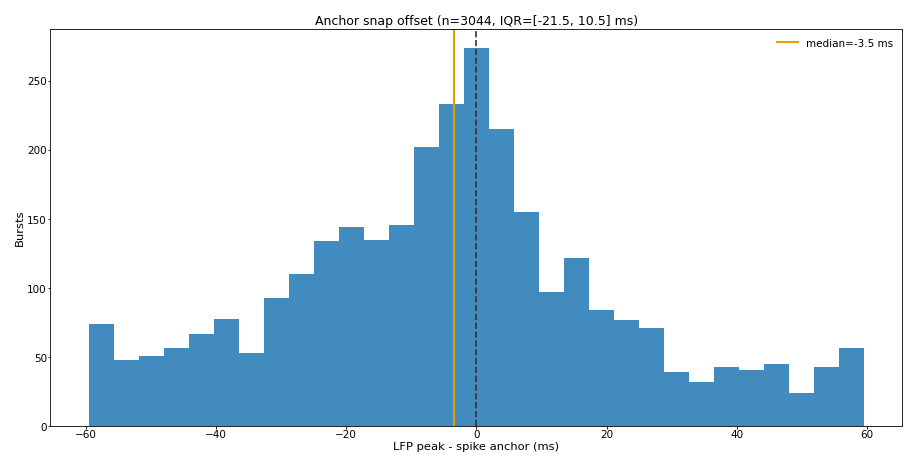

In [126]:
def plot_offset_diagnostic(table):
    offsets = table["anchor_offset_ms"].to_numpy(float)
    offsets = offsets[np.isfinite(offsets)]
    fig, ax = plt.subplots(figsize=(6.0, 3.0), constrained_layout=True)
    ax.hist(offsets, bins=31, color=PAPER_COLORS["burst"], alpha=0.85)
    med = float(np.nanmedian(offsets)) if offsets.size else np.nan
    iqr = np.nanpercentile(offsets, [25, 75]) if offsets.size else (np.nan, np.nan)
    ax.axvline(0.0, color="0.2", lw=0.8, ls="--")
    ax.axvline(med, color=PAPER_COLORS["highlight"], lw=1.0, label=f"median={med:.1f} ms")
    ax.set(xlabel="LFP peak - spike anchor (ms)", ylabel="Bursts",
           title=f"Anchor snap offset (n={offsets.size}, IQR=[{iqr[0]:.1f}, {iqr[1]:.1f}] ms)")
    ax.legend(frameon=False)
    return fig


fig_offset = plot_offset_diagnostic(anchor_table)
fig_offset.savefig(FIGURE_DIR / "anchor_snap_offset.png", dpi=300)

## Step 5 - Coherence averaging window around the snapped peak

Two separate windows: (a) the Morlet transform runs on a segment padded by `WAVELET_PAD_S`
each side so the wavelet coefficients (and hence coherence) are clean of edge/COI effects; (b)
coherence is then averaged only over `anchor +/- COH_AVG_HALF_MS` - a fixed, narrow window on
the peak, independent of burst duration. Sweep `COH_AVG_HALF_MS` to trade peak localisation
(sharp gamma/beta contrast) against averaging stability (and theta validity).

In [127]:
def coherence_window_for_burst(row):
    # Fixed averaging window centred on the snapped peak, independent of burst duration.
    anchor = float(row["lfp_anchor_time_s"])
    half_s = float(COH_AVG_HALF_MS) / 1000.0
    return anchor - half_s, anchor + half_s


def select_events_for_well(ctx, max_events=MAX_EVENTS_PER_WELL):
    bursts = ctx["bursts"].copy()
    if bursts.empty:
        return bursts
    # Strongest LFP bursts first (by population nLFP magnitude); keep that order for display.
    return bursts.sort_values("nlfp_magnitude_uv", ascending=False).head(int(max_events)).reset_index(drop=True)

## Step 6 - Per-event wavelet power + coherence spectrogram diagnostic

For a handful of bursts per well: the mean LFP trace, the Morlet power spectrogram (dB vs window
median), and the wavelet coherence spectrogram to the largest-nLFP reference. The shaded band is
the central-third coherence window; t=0 is the snapped anchor.

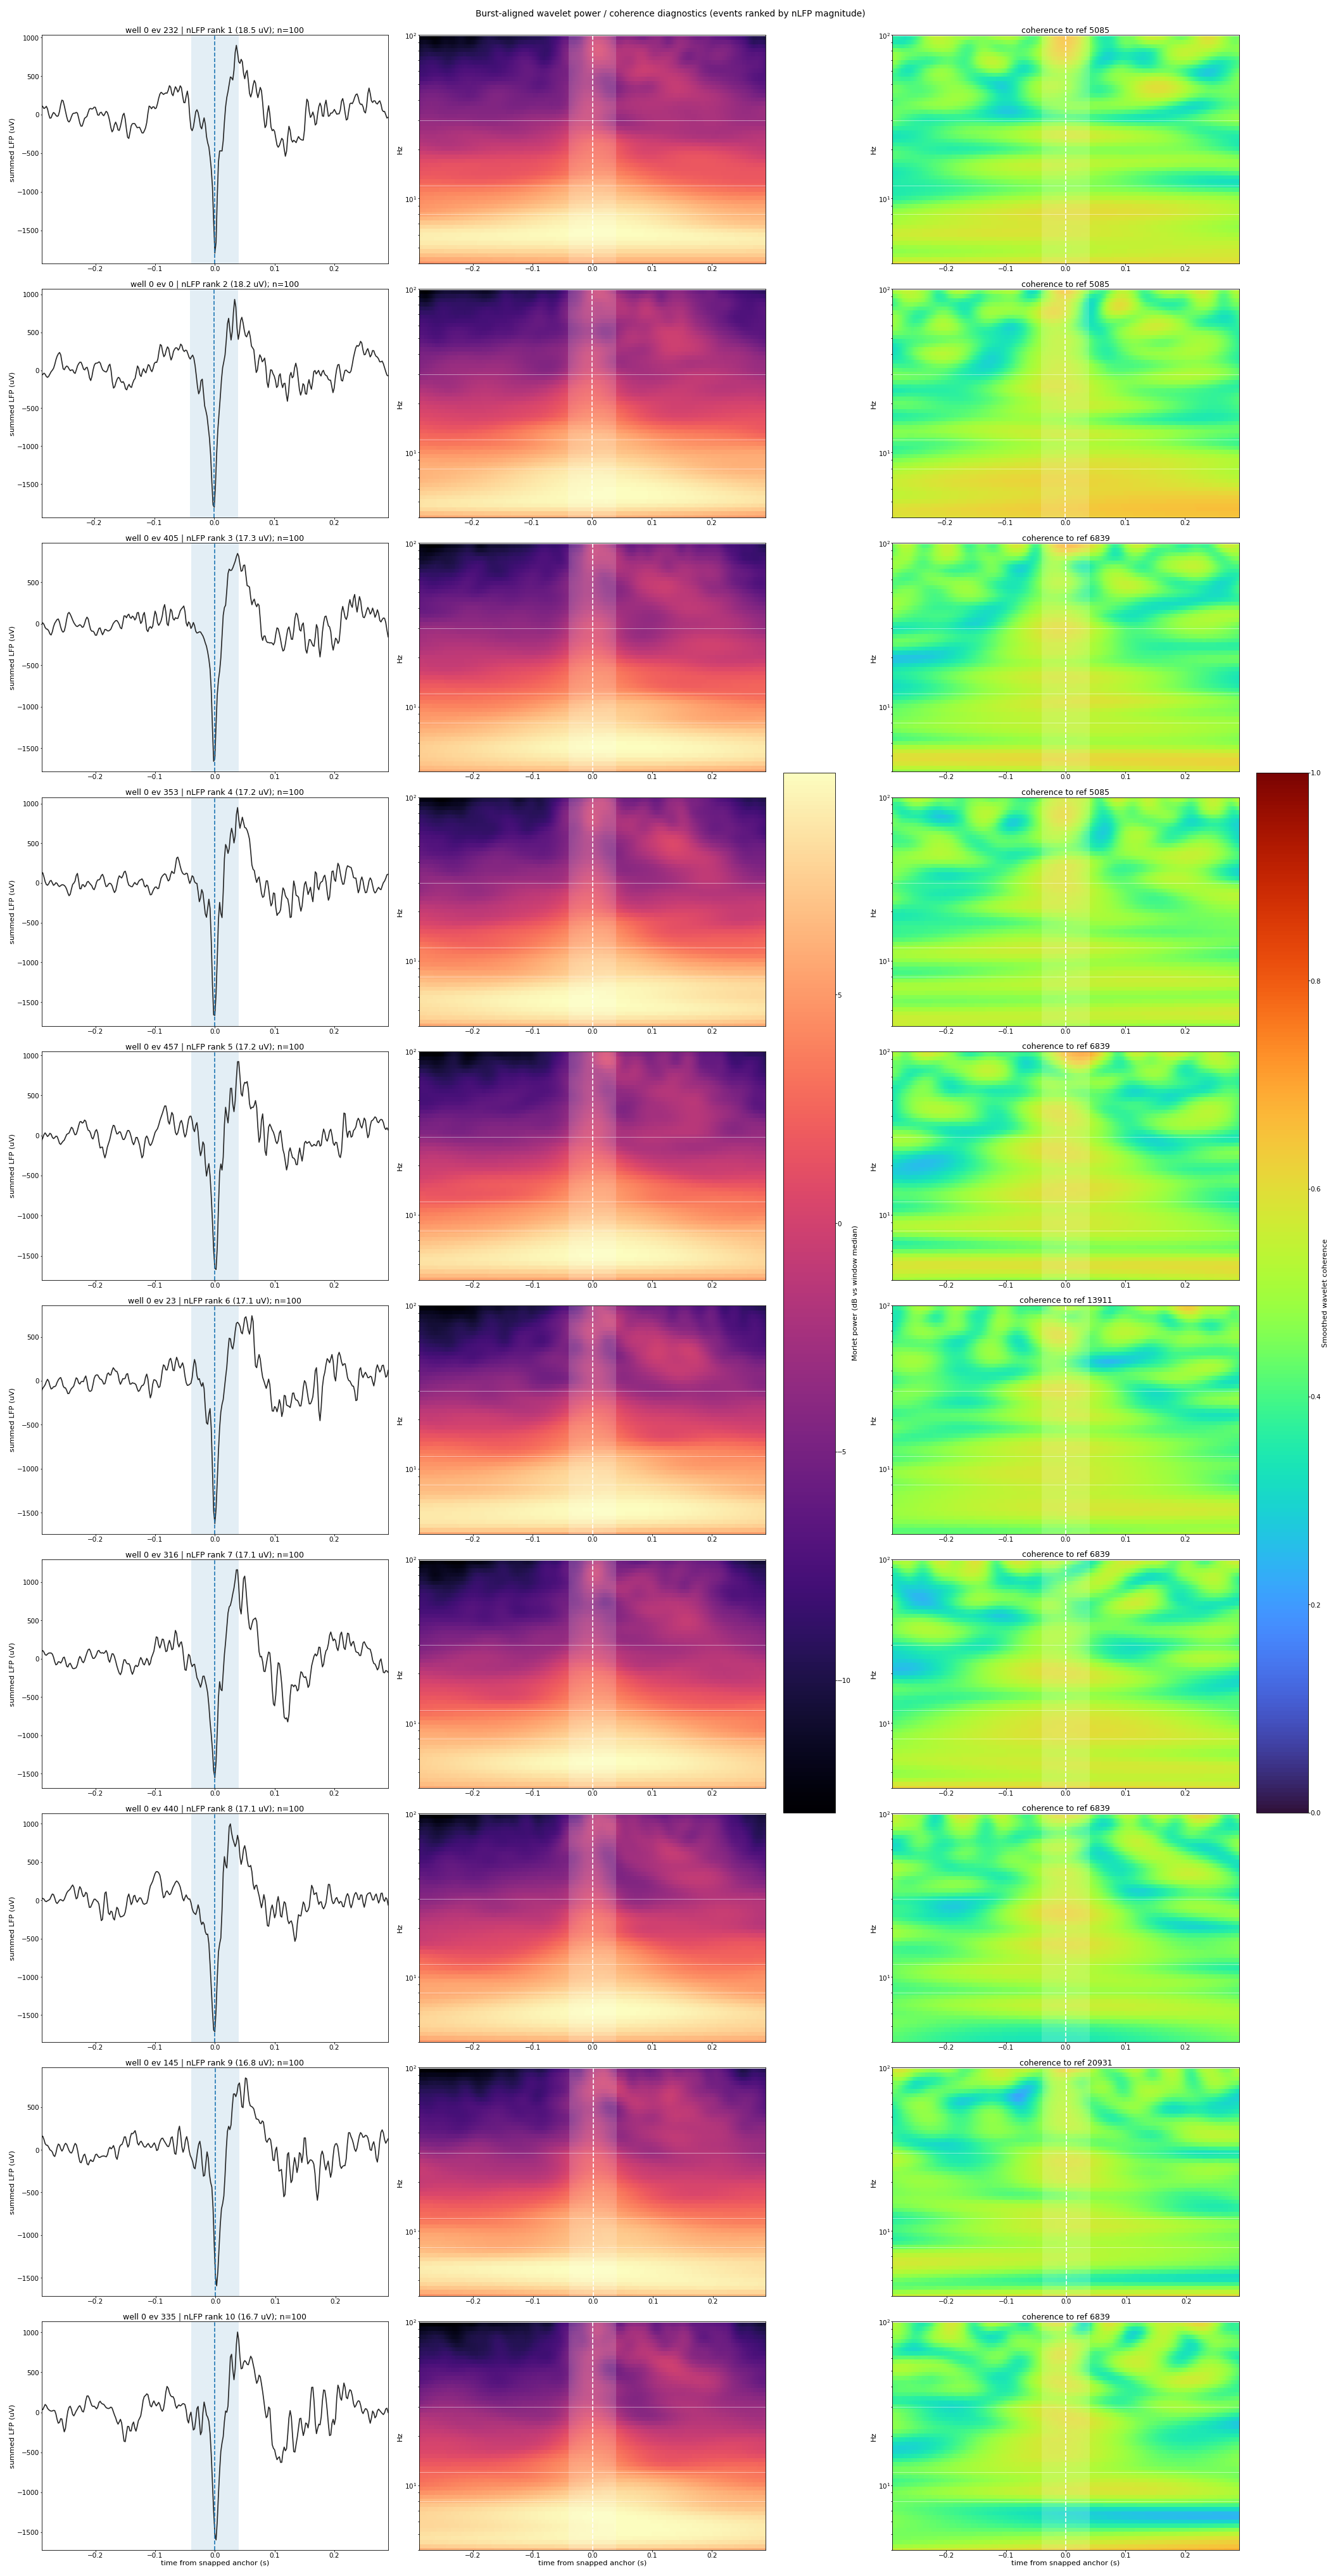

In [128]:
def build_spectrogram_diagnostics(contexts, max_events=SPECTROGRAM_N_EVENTS):
    rows = []
    for well, ctx in contexts.items():
        dataset = dataset_for_well(int(well))
        # Use the full ref population the anchor is defined on, so the summed-LFP trace minimum
        # coincides with the snapped anchor (a 12-electrode subset can drift from the population trough).
        electrodes = np.asarray(ctx["refs"], dtype=int)
        events = select_events_for_well(ctx, max_events=max_events)
        for row in events.itertuples(index=False):
            anchor = float(row.lfp_anchor_time_s)
            w_start, w_stop = coherence_window_for_burst(row._asdict())
            disp_start, disp_stop = w_start - SPECTROGRAM_PAD_S, w_stop + SPECTROGRAM_PAD_S
            # Load with extra WAVELET_PAD_S so low-freq coherence/power are free of edge/COI bias
            # (same padding as the analysis), then crop to the display range. Without this, theta
            # coherence is spuriously inflated relative to the aggregated spectrum.
            seg_start, seg_stop = disp_start - WAVELET_PAD_S, disp_stop + WAVELET_PAD_S
            segment = load_lfp_segment(dataset, 0.5 * (seg_start + seg_stop), seg_stop - seg_start, electrodes, min_channels=2)
            if segment is None:
                continue
            coeffs = morlet_coefficients(segment["data"])
            power = np.nanmean(np.abs(coeffs) ** 2, axis=2)
            win_mask = (segment["t_s"] >= w_start) & (segment["t_s"] <= w_stop)
            ref_idx = largest_nlfp_reference(segment["data"][win_mask] if np.any(win_mask) else segment["data"])
            if ref_idx is None:
                continue
            coherence_tf = wavelet_coherence_time_frequency(coeffs, ref_idx)
            disp = (segment["t_s"] >= disp_start) & (segment["t_s"] <= disp_stop)
            baseline = max(float(np.nanmedian(power[:, disp])), np.finfo(float).tiny)
            power_db = 10.0 * np.log10(np.maximum(power[:, disp], np.finfo(float).tiny) / baseline)
            rows.append({
                "well": int(well), "event_idx": int(row.event_idx), "anchor_time_s": anchor,
                "win_start_rel_s": w_start - anchor, "win_stop_rel_s": w_stop - anchor,
                "time_rel_s": segment["t_s"][disp] - anchor, "freq_hz": WAVELET_FREQS_HZ,
                "power_db": power_db, "coherence_tf": coherence_tf[:, disp],
                "ref_electrode": int(segment["electrodes"][ref_idx]),
                "summed_trace_uv": np.nansum(segment["data"][disp], axis=1) * 1e6, "n_electrodes": int(segment["data"].shape[1]),
                "nlfp_magnitude_uv": float(row.nlfp_magnitude_uv), "nlfp_rank": int(row.nlfp_rank),
            })
    return rows


def plot_spectrogram_diagnostics(rows):
    if not rows:
        print("No spectrogram diagnostics.")
        return None
    n = len(rows)
    fig, axes = plt.subplots(n, 3, figsize=(14, 2.7 * n), constrained_layout=True)
    if n == 1:
        axes = np.asarray([axes])
    img = coh_img = None
    for i, d in enumerate(rows):
        ax_tr, ax_pw, ax_co = axes[i]
        t = d["time_rel_s"]
        ax_tr.plot(t, d["summed_trace_uv"], color="0.15", lw=0.8)
        ax_tr.axvspan(d["win_start_rel_s"], d["win_stop_rel_s"], color="tab:blue", alpha=0.12, linewidth=0)
        ax_tr.axvline(0.0, color="tab:blue", lw=0.8, ls="--")
        ax_tr.set(title=f"well {d['well']} ev {d['event_idx']} | nLFP rank {d['nlfp_rank']} ({d['nlfp_magnitude_uv']:.1f} uV); n={d['n_electrodes']}", ylabel="summed LFP (uV)")
        ax_tr.set_xlim(t[0], t[-1])
        img = ax_pw.pcolormesh(t, d["freq_hz"], d["power_db"], shading="auto", cmap="magma")
        coh_img = ax_co.pcolormesh(t, d["freq_hz"], d["coherence_tf"], shading="auto", cmap="turbo", vmin=0.0, vmax=1.0)
        for ax in (ax_pw, ax_co):
            ax.axvspan(d["win_start_rel_s"], d["win_stop_rel_s"], color="white", alpha=0.16, linewidth=0)
            ax.axvline(0.0, color="white", lw=0.8, ls="--")
            for b in (8.0, 12.0, 30.0):
                ax.axhline(b, color="white", lw=0.5, alpha=0.45)
            ax.set_yscale("log")
            ax.set_ylim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
            ax.set_xlim(t[0], t[-1])
        ax_pw.set_ylabel("Hz")
        ax_co.set(ylabel="Hz", title=f"coherence to ref {d['ref_electrode']}")
    for j in range(3):
        axes[-1, j].set_xlabel("time from snapped anchor (s)")
    if img is not None:
        fig.colorbar(img, ax=axes[:, 1], shrink=0.9, label="Morlet power (dB vs window median)")
        fig.colorbar(coh_img, ax=axes[:, 2], shrink=0.9, label="Smoothed wavelet coherence")
    fig.suptitle("Burst-aligned wavelet power / coherence diagnostics (events ranked by nLFP magnitude)")
    return fig


spectrogram_diagnostics = build_spectrogram_diagnostics({EXAMPLE_WELL: anchor_contexts[EXAMPLE_WELL]})
fig_spec = plot_spectrogram_diagnostics(spectrogram_diagnostics)
if fig_spec is not None:
    fig_spec.savefig(FIGURE_DIR / "wavelet_spectrogram_diagnostic.png", dpi=300, bbox_inches="tight")

## Step 7 - Coherence over distance (wavelet)

For each selected burst: load the fixed peak averaging window plus Morlet padding, compute the CWT, pick
the largest-nLFP reference, and for each band and inter-electrode-distance bin compute the
smoothed wavelet coherence between the reference and the targets in that bin, averaged over the
band frequencies and the window time samples. Background windows are time-shifted copies of the
same window (reference kept at burst time), giving a burst-vs-shifted contrast per distance.

In [129]:
def _random_shift_center(anchor_s, window_s, recording_stop_s, bursts, rng):
    half = 0.5 * float(window_s)
    starts = bursts["start_time_s"].to_numpy(float)
    stops = bursts["end_time_s"].to_numpy(float)
    for _ in range(BACKGROUND_TRIES):
        shift = rng.uniform(-BACKGROUND_SHIFT_MAX_S, BACKGROUND_SHIFT_MAX_S)
        if abs(shift) < float(window_s):
            continue
        center = float(anchor_s) + shift
        if center - half < 0 or center + half > float(recording_stop_s):
            continue
        if np.any((stops > center - half) & (starts < center + half)):
            continue
        return center
    return np.nan


def event_wavelet_rows(segment, time_mask, coeffs, ref_idx, *, well, event_idx, anchor_s, condition, target_coeffs=None, shift_rep=np.nan):
    target_coeffs = coeffs if target_coeffs is None else target_coeffs
    coords = np.asarray(segment["coords_um"], dtype=float)
    distance_um = np.sqrt(np.sum((coords - coords[ref_idx][None, :]) ** 2, axis=1))
    edges, centers = distance_edges_and_centers()
    bin_idx = np.searchsorted(edges, distance_um, side="right") - 1
    keep_site = (np.arange(coords.shape[0]) != ref_idx) & (bin_idx >= 0) & (bin_idx < centers.size) & np.isfinite(distance_um)
    distance_rows, freq_rows = [], []
    peak_specs = {bn: _peak_frequency_from_power(coeffs, band, time_mask) for bn, band in FREQUENCY_BANDS.items()}
    targets_all = np.flatnonzero(keep_site)
    if targets_all.size == 0:
        return distance_rows, freq_rows, peak_specs
    # Per-pair coherence maps (freq, time, n_targets) computed once, then averaged per band / distance bin.
    pair = pairwise_coherence_maps(coeffs, ref_idx, target_coeffs, targets_all)
    target_bins = bin_idx[targets_all]
    time_idx = np.flatnonzero(time_mask)

    for band_name, band in FREQUENCY_BANDS.items():
        freq_idx = np.flatnonzero(_band_frequency_mask(band))
        if freq_idx.size == 0 or time_idx.size < 3:
            continue
        band_map = pair[freq_idx][:, time_idx, :]  # (Fband, Twin, J)
        for b in np.unique(target_bins):
            cols = np.flatnonzero(target_bins == b)
            value = float(np.nanmean(band_map[:, :, cols]))
            if not np.isfinite(value):
                continue
            distance_rows.append({
                "well": int(well), "event_idx": int(event_idx), "condition": condition, "shift_rep": shift_rep,
                "band": band_name, "distance_bin_center_um": float(centers[int(b)]), "coherence": value,
                "n_sites": int(cols.size), "ref_electrode": int(segment["electrodes"][ref_idx]),
            })

    spectrum = np.nanmean(pair[:, time_idx, :], axis=(1, 2))  # mean over time and targets -> per frequency
    for fi, freq_hz in enumerate(WAVELET_FREQS_HZ):
        if LINE_NOISE_EXCLUSION_HZ is not None and LINE_NOISE_EXCLUSION_HZ[0] <= float(freq_hz) <= LINE_NOISE_EXCLUSION_HZ[1]:
            continue
        if np.isfinite(spectrum[fi]):
            freq_rows.append({
                "well": int(well), "event_idx": int(event_idx), "condition": condition, "shift_rep": shift_rep,
                "frequency_hz": float(freq_hz), "coherence": float(spectrum[fi]), "n_sites": int(targets_all.size),
            })
    return distance_rows, freq_rows, peak_specs


def compute_well_coherence(ctx, *, rng):
    well = int(ctx["well"])
    dataset = dataset_for_well(well)
    electrodes = np.asarray(ctx["refs"], dtype=int)
    bursts = ctx["bursts"]
    recording_stop_s = float(ctx["info"]["raw_shape"][1]) / float(ctx["info"]["fs_raw"])
    events = select_events_for_well(ctx)
    distance_rows, freq_rows, selected = [], [], []
    band_freq_idx = {bn: np.flatnonzero(_band_frequency_mask(band)) for bn, band in FREQUENCY_BANDS.items()}
    site_power_sum = None
    site_count = 0
    site_coords = site_elec = None
    for row in events.itertuples(index=False):
        event_idx = int(row.event_idx)
        anchor = float(row.lfp_anchor_time_s)
        w_start, w_stop = coherence_window_for_burst(row._asdict())
        window_s = (w_stop - w_start) + 2.0 * WAVELET_PAD_S
        center = 0.5 * (w_start + w_stop)
        segment = load_lfp_segment(dataset, center, window_s, electrodes, min_channels=2)
        if segment is None:
            continue
        time_mask = (segment["t_s"] >= w_start) & (segment["t_s"] <= w_stop)
        if np.count_nonzero(time_mask) < 3:
            continue
        coeffs = morlet_coefficients(segment["data"])
        ref_idx = largest_nlfp_reference(segment["data"][time_mask])
        if ref_idx is None:
            continue
        d_rows, f_rows, peaks = event_wavelet_rows(segment, time_mask, coeffs, ref_idx, well=well, event_idx=event_idx, anchor_s=anchor, condition="burst")
        distance_rows.extend(d_rows)
        freq_rows.extend(f_rows)
        # per-electrode band power over the burst window (for the spatial site map)
        power_all = np.abs(coeffs) ** 2
        ti = np.flatnonzero(time_mask)
        band_powers = np.stack([np.nanmean(power_all[band_freq_idx[bn]][:, ti, :], axis=(0, 1)) for bn in FREQUENCY_BANDS], axis=0)
        if site_power_sum is None:
            site_power_sum = np.zeros_like(band_powers)
            site_coords = np.asarray(segment["coords_um"], dtype=float)
            site_elec = np.asarray(segment["electrodes"], dtype=int)
        if band_powers.shape == site_power_sum.shape and np.array_equal(np.asarray(segment["electrodes"], dtype=int), site_elec):
            site_power_sum += band_powers
            site_count += 1
        print(f"well {well} event {event_idx}: window {w_start:.3f}-{w_stop:.3f}s, ref {int(segment['electrodes'][ref_idx])}, sites {segment['data'].shape[1]}")
        for shift_rep in range(1, int(SHIFT_REPS) + 1):
            bg_center = _random_shift_center(anchor, window_s, recording_stop_s, bursts, rng)
            if not np.isfinite(bg_center):
                continue
            bg = load_lfp_segment(dataset, bg_center, window_s, segment["electrodes"], min_channels=2)
            if bg is None or bg["data"].shape != segment["data"].shape or not np.array_equal(bg["electrodes"], segment["electrodes"]):
                continue
            bg_coeffs = morlet_coefficients(bg["data"])
            d_rows, f_rows, _ = event_wavelet_rows(segment, time_mask, coeffs, ref_idx, well=well, event_idx=event_idx, anchor_s=anchor, condition="shifted", target_coeffs=bg_coeffs, shift_rep=shift_rep)
            distance_rows.extend(d_rows)
            freq_rows.extend(f_rows)
        selected.append({
            "well": well, "event_idx": event_idx, "anchor_time_s": float(row.anchor_time_s), "lfp_anchor_time_s": anchor,
            "anchor_offset_ms": float(row.anchor_offset_ms), "window_start_s": w_start, "window_stop_s": w_stop,
            "ref_electrode": int(segment["electrodes"][ref_idx]), "n_sites": int(segment["data"].shape[1]),
            "nlfp_magnitude_uv": float(row.nlfp_magnitude_uv), "nlfp_rank": int(row.nlfp_rank),
            "theta_peak_hz": peaks.get("theta", np.nan), "beta_peak_hz": peaks.get("beta", np.nan), "gamma_peak_hz": peaks.get("gamma", np.nan),
        })
    site_rows = []
    if site_count > 0:
        mean_bp = site_power_sum / float(site_count)
        for bi, bn in enumerate(FREQUENCY_BANDS):
            for ci in range(site_elec.size):
                site_rows.append({
                    "well": well, "electrode": int(site_elec[ci]),
                    "x_um": float(site_coords[ci, 0]), "y_um": float(site_coords[ci, 1]),
                    "band": bn, "power": float(mean_bp[bi, ci]), "n_events": int(site_count),
                })
    return distance_rows, freq_rows, selected, site_rows


def compute_all_coherence(contexts):
    all_d, all_f, all_sel, all_site = [], [], [], []
    for well, ctx in contexts.items():
        t0 = perf_counter()
        rng = np.random.default_rng(RANDOM_SEED + int(well))
        d_rows, f_rows, sel, site_rows = compute_well_coherence(ctx, rng=rng)
        all_d.extend(d_rows); all_f.extend(f_rows); all_sel.extend(sel); all_site.extend(site_rows)
        print(f"well {well}: coherence elapsed={perf_counter() - t0:.1f}s")
    return {
        "config": CONFIG, "anchor_table": anchor_table,
        "event_distance_coherence": pd.DataFrame(all_d), "frequency_coherence": pd.DataFrame(all_f),
        "selected_events": pd.DataFrame(all_sel), "site_band_power": pd.DataFrame(all_site),
    }


product = None
if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    with CACHE_PATH.open("rb") as fh:
        cached = pickle.load(fh)
    if cached.get("config") == CONFIG:
        product = cached
        print(f"Loaded cached product: {CACHE_PATH}")
    else:
        print("Ignoring cache with non-matching config.")
if product is None:
    product = compute_all_coherence(anchor_contexts)
    with CACHE_PATH.open("wb") as fh:
        pickle.dump(product, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved product: {CACHE_PATH}")

event_distance_coherence = product["event_distance_coherence"]
frequency_coherence = product["frequency_coherence"]
selected_events = product["selected_events"]
site_band_power = product.get("site_band_power", pd.DataFrame())
print({"distance_rows": len(event_distance_coherence), "frequency_rows": len(frequency_coherence), "events": len(selected_events), "site_power_rows": len(site_band_power)})
selected_events.head()

Loaded cached product: /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance_div12_wavelet_snapped_anchor/wavelet_coherence_distance_cache.pkl
{'distance_rows': 96153, 'frequency_rows': 63030, 'events': 300, 'site_power_rows': 1800}


,well,event_idx,anchor_time_s,lfp_anchor_time_s,anchor_offset_ms,window_start_s,window_stop_s,ref_electrode,n_sites,nlfp_magnitude_uv,nlfp_rank,theta_peak_hz,beta_peak_hz,gamma_peak_hz
0,0,232,258.0315,258.070,38.5,258.030,258.110,5085,100,18.519928,1,5.993228,12.699208,30.203978
1,0,0,16.1145,16.160,45.5,16.120,16.200,5085,100,18.246723,2,5.339359,12.699208,30.203978
2,0,405,457.0015,457.002,0.5,456.962,457.042,6839,100,17.335589,3,5.656854,12.699208,30.203978
3,0,353,390.0205,390.056,35.5,390.016,390.096,5085,100,17.227296,4,5.656854,12.699208,30.203978
4,0,457,529.9285,529.928,-0.5,529.888,529.968,6839,100,17.205830,5,5.656854,12.699208,30.203978


## Step 8 - Summaries

In [130]:
def bootstrap_ci(values, reps=BOOTSTRAP_REPS, seed=RANDOM_SEED, statistic=np.nanmean):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(int(seed))
    boot = np.array([statistic(rng.choice(values, size=values.size, replace=True)) for _ in range(int(reps))])
    return tuple(np.nanpercentile(boot, [2.5, 50.0, 97.5]))


def summarize_frequency_coherence(freq_df):
    if freq_df.empty:
        return pd.DataFrame()
    return (
        freq_df.groupby(["condition", "frequency_hz"], as_index=False)
        .agg(coherence_mean=("coherence", "mean"), coherence_median=("coherence", "median"), n_events=("event_idx", "nunique"))
        .sort_values(["condition", "frequency_hz"])
    )


def compute_relative_event_distance(event_distance):
    key = ["well", "event_idx", "band", "distance_bin_center_um"]
    if event_distance.empty:
        return pd.DataFrame()
    pivot = event_distance.pivot_table(index=key, columns="condition", values="coherence", aggfunc="mean").reset_index()
    if "burst" not in pivot or "shifted" not in pivot:
        return pd.DataFrame()
    pivot = pivot[np.isfinite(pivot["burst"]) & np.isfinite(pivot["shifted"]) & (pivot["shifted"] > 0)].copy()
    pivot["coherence_relative"] = pivot["burst"] / pivot["shifted"]
    return pivot


def hierarchical_relative_summary(relative_df):
    if relative_df.empty:
        return pd.DataFrame()
    rng = np.random.default_rng(RANDOM_SEED + 2000)
    wells = np.asarray(sorted(relative_df["well"].unique()), dtype=int)
    rows = []
    for (band, distance), group in relative_df.groupby(["band", "distance_bin_center_um"], sort=True):
        observed = group.groupby("well")["coherence_relative"].mean().mean()
        boot = []
        for _ in range(int(BOOTSTRAP_REPS)):
            sampled = []
            for well in rng.choice(wells, size=wells.size, replace=True):
                vals = group.loc[group["well"] == well, "coherence_relative"].to_numpy(float)
                vals = vals[np.isfinite(vals)]
                if vals.size:
                    sampled.append(np.nanmean(rng.choice(vals, size=vals.size, replace=True)))
            if sampled:
                boot.append(np.nanmean(sampled))
        lo, med, hi = np.nanpercentile(boot, [2.5, 50.0, 97.5]) if boot else (np.nan, np.nan, np.nan)
        rows.append({
            "band": str(band), "distance_bin_center_um": float(distance), "coherence_relative_mean": float(observed),
            "coherence_relative_ci_low": float(lo), "coherence_relative_ci_high": float(hi),
            "n_wells": int(group["well"].nunique()), "n_events": int(group[["well", "event_idx"]].drop_duplicates().shape[0]),
        })
    return pd.DataFrame(rows)


def summarize_condition_distance(event_distance):
    if event_distance.empty:
        return pd.DataFrame()
    rows = []
    for key, group in event_distance.groupby(["condition", "band", "distance_bin_center_um"], sort=True):
        condition, band, distance = key
        lo, med, hi = bootstrap_ci(group["coherence"].to_numpy(float))
        rows.append({
            "condition": condition, "band": band, "distance_bin_center_um": float(distance),
            "coherence_mean": float(np.nanmean(group["coherence"])), "coherence_ci_low": lo, "coherence_ci_high": hi,
            "n_events": int(group[["well", "event_idx"]].drop_duplicates().shape[0]),
        })
    return pd.DataFrame(rows)


frequency_summary = summarize_frequency_coherence(frequency_coherence)
relative_event_distance = compute_relative_event_distance(event_distance_coherence)
relative_distance_summary = hierarchical_relative_summary(relative_event_distance)
condition_distance_summary = summarize_condition_distance(event_distance_coherence)

if SAVE_TABLES:
    anchor_table.to_csv(TABLE_DIR / "event_anchors.csv", index=False)
    selected_events.to_csv(TABLE_DIR / "selected_events.csv", index=False)
    if not site_band_power.empty:
        site_band_power.to_csv(TABLE_DIR / "site_band_power.csv", index=False)
    event_distance_coherence.to_csv(TABLE_DIR / "event_distance_coherence.csv", index=False)
    frequency_coherence.to_csv(TABLE_DIR / "frequency_coherence.csv", index=False)
    frequency_summary.to_csv(TABLE_DIR / "frequency_summary.csv", index=False)
    condition_distance_summary.to_csv(TABLE_DIR / "condition_distance_summary.csv", index=False)
    relative_distance_summary.to_csv(TABLE_DIR / "relative_distance_summary.csv", index=False)
    pd.DataFrame([{k: str(v) for k, v in CONFIG.items()}]).to_csv(TABLE_DIR / "method_config.csv", index=False)
    print(f"Saved tables to {TABLE_DIR}")

frequency_summary.head(), relative_distance_summary.head()

Saved tables to /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance_div12_wavelet_snapped_anchor/tables


(  condition  frequency_hz  coherence_mean  coherence_median  n_events
 0     burst      4.000000        0.624427          0.641634       244
 1     burst      4.237852        0.600764          0.615866       244
 2     burst      4.489848        0.583166          0.599142       244
 3     burst      4.756828        0.570395          0.581163       244
 4     burst      5.039684        0.559798          0.572898       244,
    band  distance_bin_center_um  coherence_relative_mean  \
 0  beta                   100.0                 1.063180   
 1  beta                   200.0                 1.116015   
 2  beta                   300.0                 1.076932   
 3  beta                   400.0                 1.071190   
 4  beta                   500.0                 1.088010   
 
    coherence_relative_ci_low  coherence_relative_ci_high  n_wells  n_events  
 0                   0.987393                    1.158513        6       115  
 1                   1.048332                  

## Step 9 - Figures

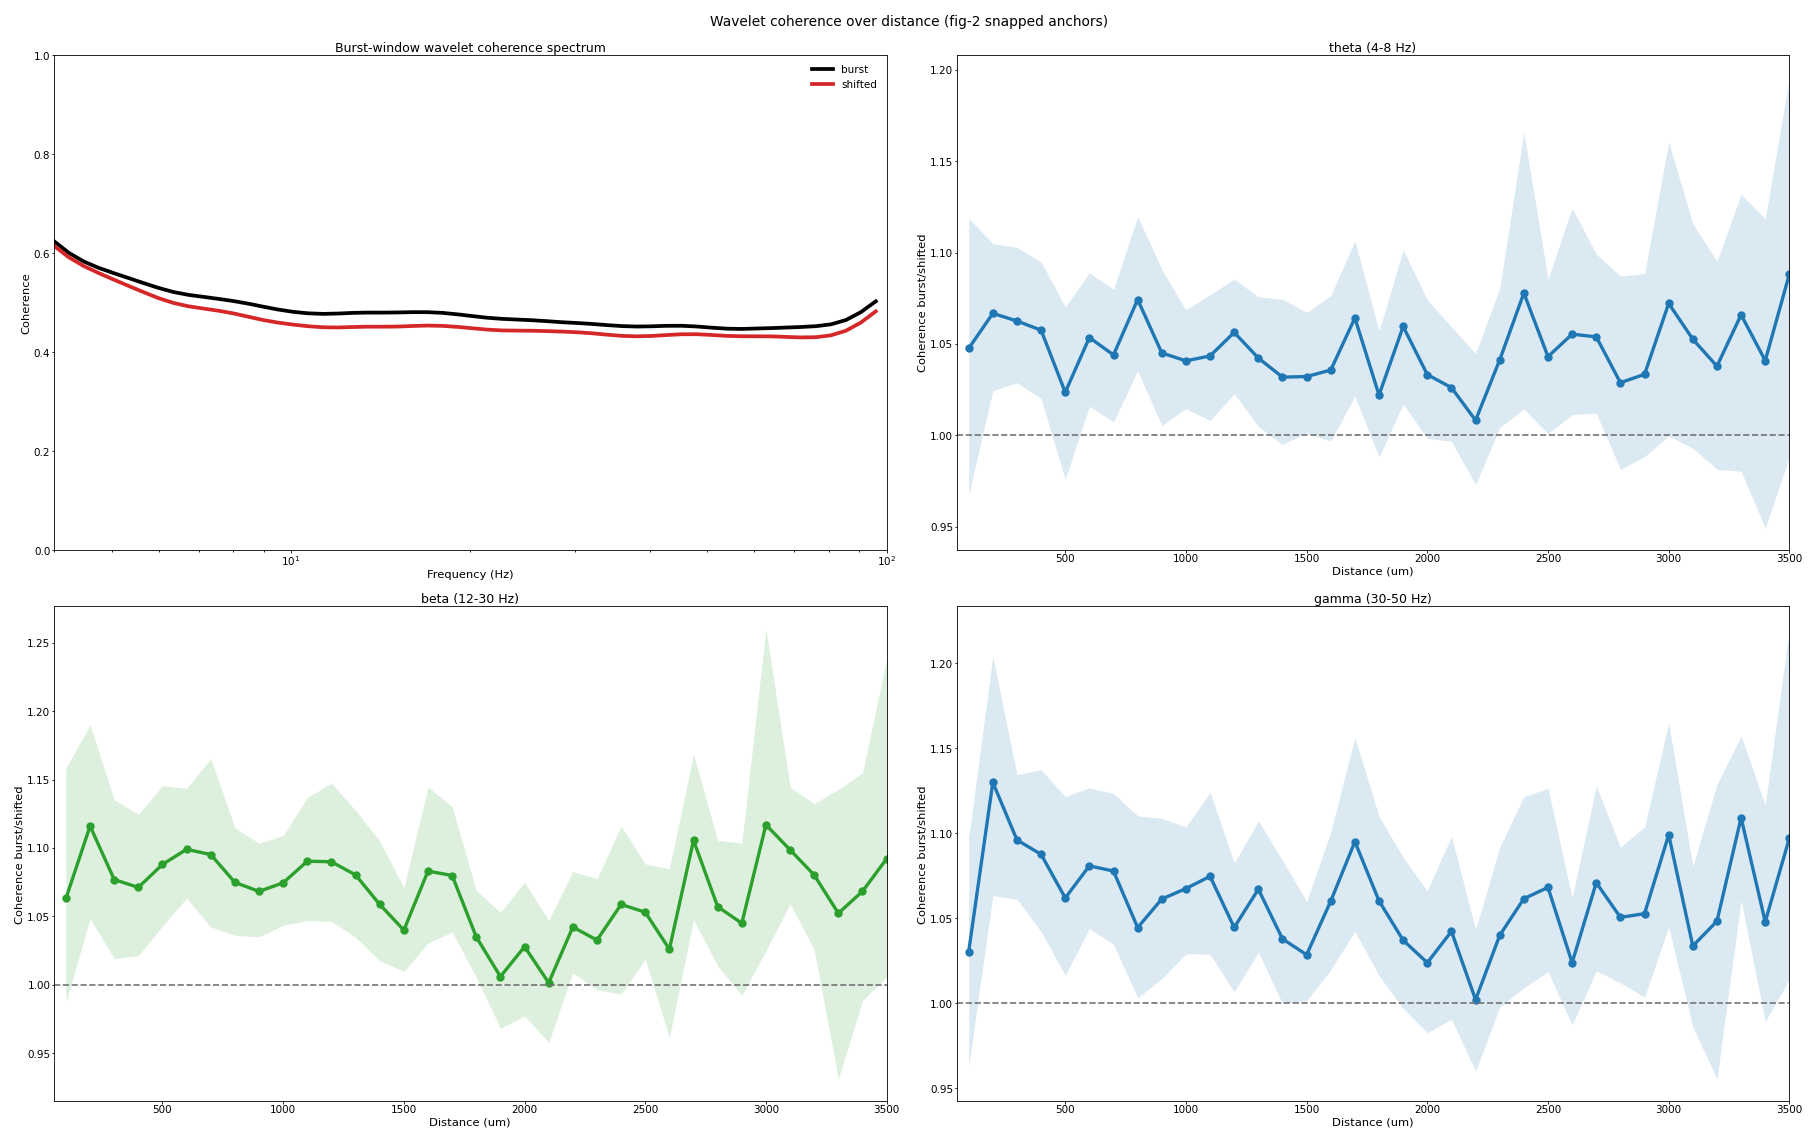

In [131]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), constrained_layout=True)

ax = axes[0, 0]
if not frequency_summary.empty:
    for condition, group in frequency_summary.groupby("condition"):
        group = group.sort_values("frequency_hz")
        color = "black" if condition == "burst" else "tab:red"
        ax.plot(group["frequency_hz"], group["coherence_mean"], color=color, lw=1.8, label=condition)
ax.set(title="Burst-window wavelet coherence spectrum", xlabel="Frequency (Hz)", ylabel="Coherence")
ax.set_xscale("log")
ax.set_xlim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
ax.set_ylim(0, 1)
ax.legend(frameon=False)

band_colors = {"theta": "tab:blue", "beta": "tab:green", "gamma": PAPER_COLORS["burst"]}
for ax, band in zip([axes[0, 1], axes[1, 0], axes[1, 1]], ["theta", "beta", "gamma"]):
    rel = relative_distance_summary.loc[relative_distance_summary["band"] == band].sort_values("distance_bin_center_um") if not relative_distance_summary.empty else pd.DataFrame()
    if rel.empty:
        ax.set_axis_off()
        continue
    x = rel["distance_bin_center_um"].to_numpy(float)
    y = rel["coherence_relative_mean"].to_numpy(float)
    lo = rel["coherence_relative_ci_low"].to_numpy(float)
    hi = rel["coherence_relative_ci_high"].to_numpy(float)
    ax.plot(x, y, marker="o", color=band_colors[band], lw=1.6, ms=3.0)
    ax.fill_between(x, lo, hi, color=band_colors[band], alpha=0.16, linewidth=0)
    ax.axhline(1.0, color="0.45", lw=0.8, ls="--")
    low, high = FREQUENCY_BANDS[band]
    ax.set(title=f"{band} ({low:g}-{high:g} Hz)", xlabel="Distance (um)", ylabel="Coherence burst/shifted")
    ax.set_xlim(MIN_DISTANCE_UM, MAX_DISTANCE_UM)

fig.suptitle("Wavelet coherence over distance (fig-2 snapped anchors)")
fig.savefig(FIGURE_DIR / "wavelet_coherence_over_distance.png", dpi=300, bbox_inches="tight")

## Step 9b - Coherence over distance vs top-n strongest events

The fig-2 detector is permissive, so averaging over all events dilutes the effect. Here the
relative coherence-over-distance is recomputed over the top-n events by population nLFP magnitude,
for a sweep of n. If weak / noise "bursts" are washing out the signal, small n should show a
stronger burst/shifted ratio and a clearer distance dependence than large n.

,band,distance_bin_center_um,coherence_relative_mean,coherence_relative_ci_low,coherence_relative_ci_high,n_wells,n_events,top_n
0,beta,100.0,1.211523,1.093203,1.322139,4,12,5
1,beta,200.0,1.202818,1.073635,1.336532,6,26,5
2,beta,300.0,1.159444,1.045593,1.276796,6,28,5
3,beta,400.0,1.196765,1.090660,1.325999,6,26,5
4,beta,500.0,1.223690,1.019082,1.507962,6,23,5


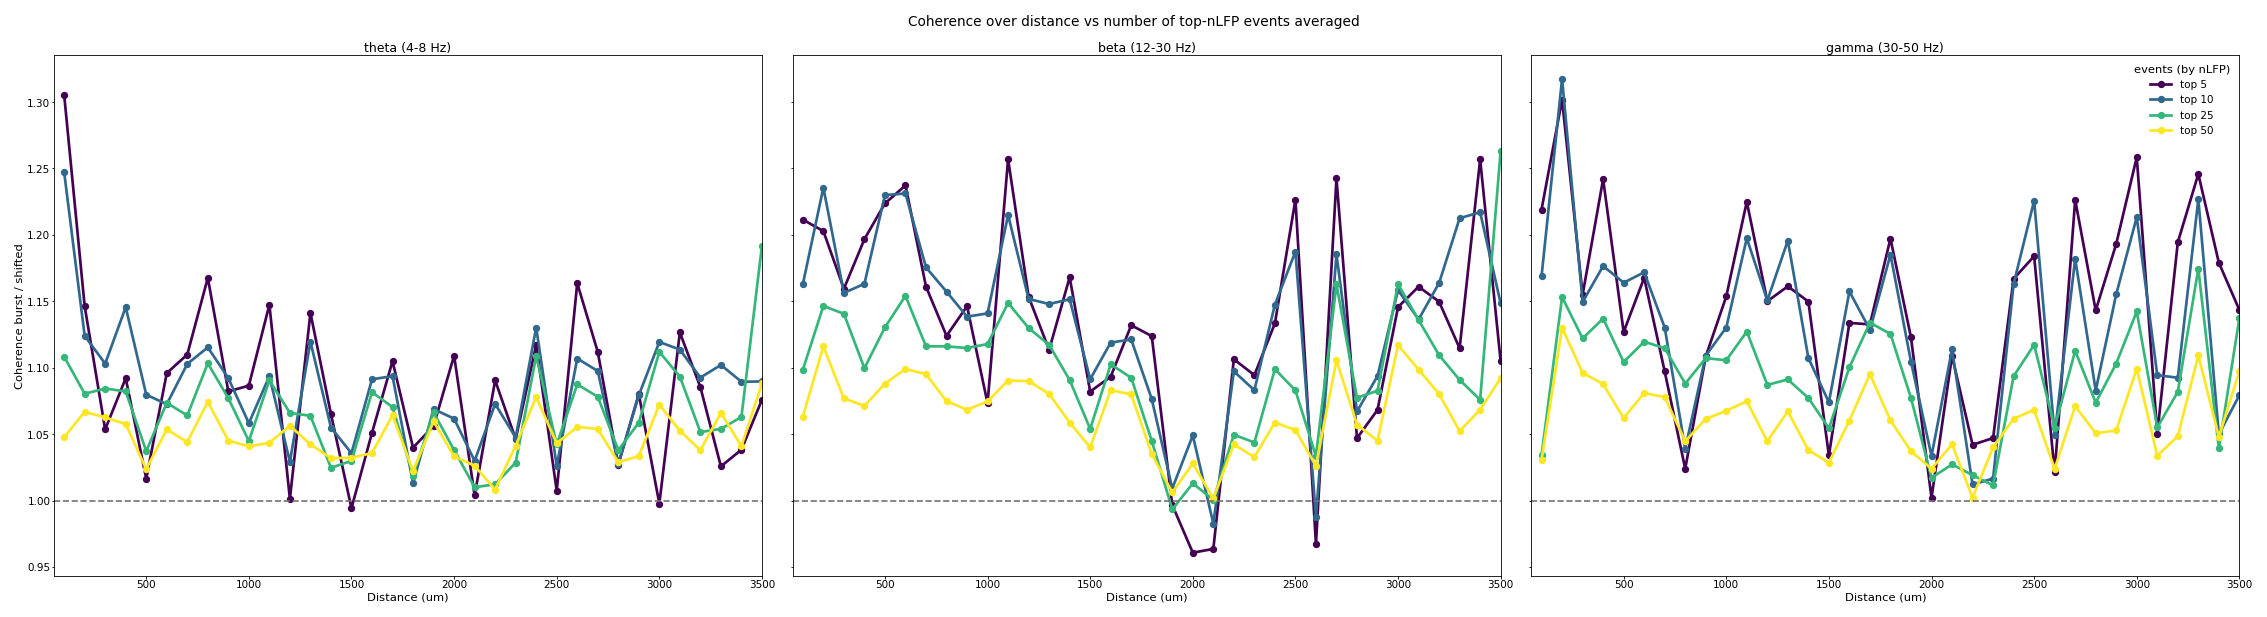

In [132]:
def relative_distance_by_top_n(event_distance, selected_events, n_values):
    if event_distance.empty or selected_events.empty:
        return pd.DataFrame()
    ranks = selected_events[["well", "event_idx", "nlfp_rank"]].drop_duplicates()
    ed = event_distance.merge(ranks, on=["well", "event_idx"], how="left")
    frames = []
    for n in n_values:
        rel = compute_relative_event_distance(ed[ed["nlfp_rank"] <= int(n)])
        summ = hierarchical_relative_summary(rel)
        if not summ.empty:
            summ["top_n"] = int(n)
            frames.append(summ)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


topn_distance_summary = relative_distance_by_top_n(event_distance_coherence, selected_events, TOP_N_SWEEP)
if SAVE_TABLES and not topn_distance_summary.empty:
    topn_distance_summary.to_csv(TABLE_DIR / "topn_relative_distance_summary.csv", index=False)

if topn_distance_summary.empty:
    print("No top-n sweep summary (need both burst and shifted rows).")
else:
    n_vals = sorted(topn_distance_summary["top_n"].unique())
    cmap = plt.get_cmap("viridis")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.0), constrained_layout=True, sharey=True)
    for ax, band in zip(axes, ["theta", "beta", "gamma"]):
        for i, n in enumerate(n_vals):
            g = topn_distance_summary[(topn_distance_summary.band == band) & (topn_distance_summary.top_n == n)].sort_values("distance_bin_center_um")
            if g.empty:
                continue
            ax.plot(g["distance_bin_center_um"], g["coherence_relative_mean"], marker="o", ms=2.5, lw=1.3,
                    color=cmap(i / max(1, len(n_vals) - 1)), label=f"top {n}")
        ax.axhline(1.0, color="0.45", lw=0.8, ls="--")
        low, high = FREQUENCY_BANDS[band]
        ax.set(title=f"{band} ({low:g}-{high:g} Hz)", xlabel="Distance (um)")
        ax.set_xlim(MIN_DISTANCE_UM, MAX_DISTANCE_UM)
    axes[0].set_ylabel("Coherence burst / shifted")
    axes[-1].legend(frameon=False, title="events (by nLFP)")
    fig.suptitle("Coherence over distance vs number of top-nLFP events averaged")
    fig.savefig(FIGURE_DIR / "wavelet_coherence_over_distance_topn_sweep.png", dpi=300, bbox_inches="tight")

topn_distance_summary.head()

## Step 9c - Coherence spectrum vs top-n strongest events

The same top-n treatment applied to the burst-window wavelet coherence spectrum: per-frequency
coherence (hierarchical mean across wells of the per-event mean), one curve per top-n. Solid =
burst window, dashed = time-shifted background. As weaker events are added (larger n) the burst
spectrum should drop toward the shifted baseline.

,condition,frequency_hz,coherence_mean,top_n
0,burst,4.000000,0.635738,5
1,burst,4.237852,0.621853,5
2,burst,4.489848,0.613195,5
3,burst,4.756828,0.603976,5
4,burst,5.039684,0.592107,5


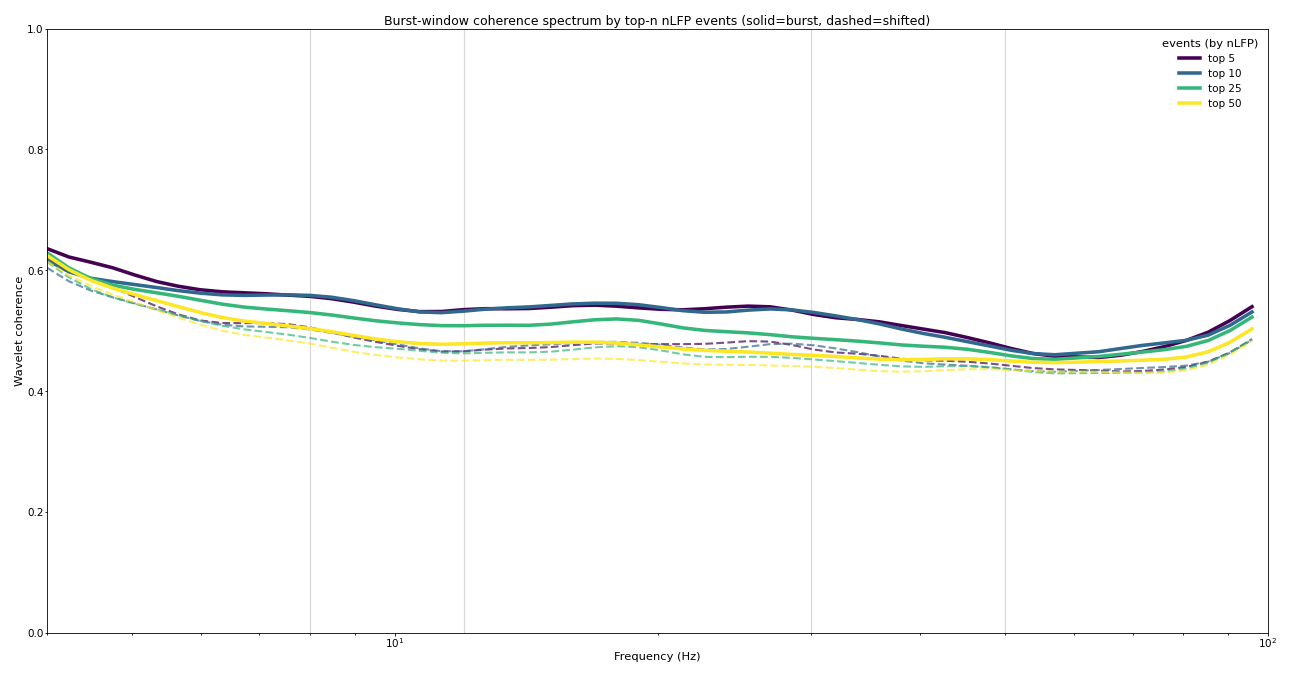

In [133]:
def frequency_spectrum_by_top_n(frequency_coherence, selected_events, n_values):
    if frequency_coherence.empty or selected_events.empty:
        return pd.DataFrame()
    ranks = selected_events[["well", "event_idx", "nlfp_rank"]].drop_duplicates()
    fc = frequency_coherence.merge(ranks, on=["well", "event_idx"], how="left")
    frames = []
    for n in n_values:
        sub = fc[fc["nlfp_rank"] <= int(n)]
        if sub.empty:
            continue
        per_well = sub.groupby(["condition", "frequency_hz", "well"], as_index=False).agg(coherence=("coherence", "mean"))
        agg = per_well.groupby(["condition", "frequency_hz"], as_index=False).agg(coherence_mean=("coherence", "mean"))
        agg["top_n"] = int(n)
        frames.append(agg)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


topn_frequency_summary = frequency_spectrum_by_top_n(frequency_coherence, selected_events, TOP_N_SWEEP)
if SAVE_TABLES and not topn_frequency_summary.empty:
    topn_frequency_summary.to_csv(TABLE_DIR / "topn_frequency_summary.csv", index=False)

if topn_frequency_summary.empty:
    print("No top-n frequency spectrum (need both burst and shifted rows).")
else:
    n_vals = sorted(topn_frequency_summary["top_n"].unique())
    cmap = plt.get_cmap("viridis")
    fig, ax = plt.subplots(figsize=(8.5, 4.4), constrained_layout=True)
    for i, n in enumerate(n_vals):
        color = cmap(i / max(1, len(n_vals) - 1))
        b = topn_frequency_summary[(topn_frequency_summary.top_n == n) & (topn_frequency_summary.condition == "burst")].sort_values("frequency_hz")
        s = topn_frequency_summary[(topn_frequency_summary.top_n == n) & (topn_frequency_summary.condition == "shifted")].sort_values("frequency_hz")
        if not b.empty:
            ax.plot(b["frequency_hz"], b["coherence_mean"], color=color, lw=1.7, label=f"top {n}")
        if not s.empty:
            ax.plot(s["frequency_hz"], s["coherence_mean"], color=color, lw=1.0, ls="--", alpha=0.7)
    for boundary in (8.0, 12.0, 30.0, 50.0):
        ax.axvline(boundary, color="0.85", lw=0.6, zorder=0)
    ax.set_xscale("log")
    ax.set_xlim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
    ax.set_ylim(0, 1)
    ax.set(xlabel="Frequency (Hz)", ylabel="Wavelet coherence",
           title="Burst-window coherence spectrum by top-n nLFP events (solid=burst, dashed=shifted)")
    ax.legend(frameon=False, title="events (by nLFP)")
    fig.savefig(FIGURE_DIR / "wavelet_coherence_spectrum_topn.png", dpi=300, bbox_inches="tight")

topn_frequency_summary.head()

## Step 9d - Strongest band-power sites on the HD-MEA geometry

Per well and band, each analysed electrode is drawn at its physical (x, y) on the HD-MEA, coloured
by mean burst-window band power (magma; the area inside the MEA bounds is black, so unanalysed
sites stay black and the strongest theta / beta / gamma sites light up). Power is scaled per panel
(robust 99th-percentile), since absolute power differs across cultures/bands.

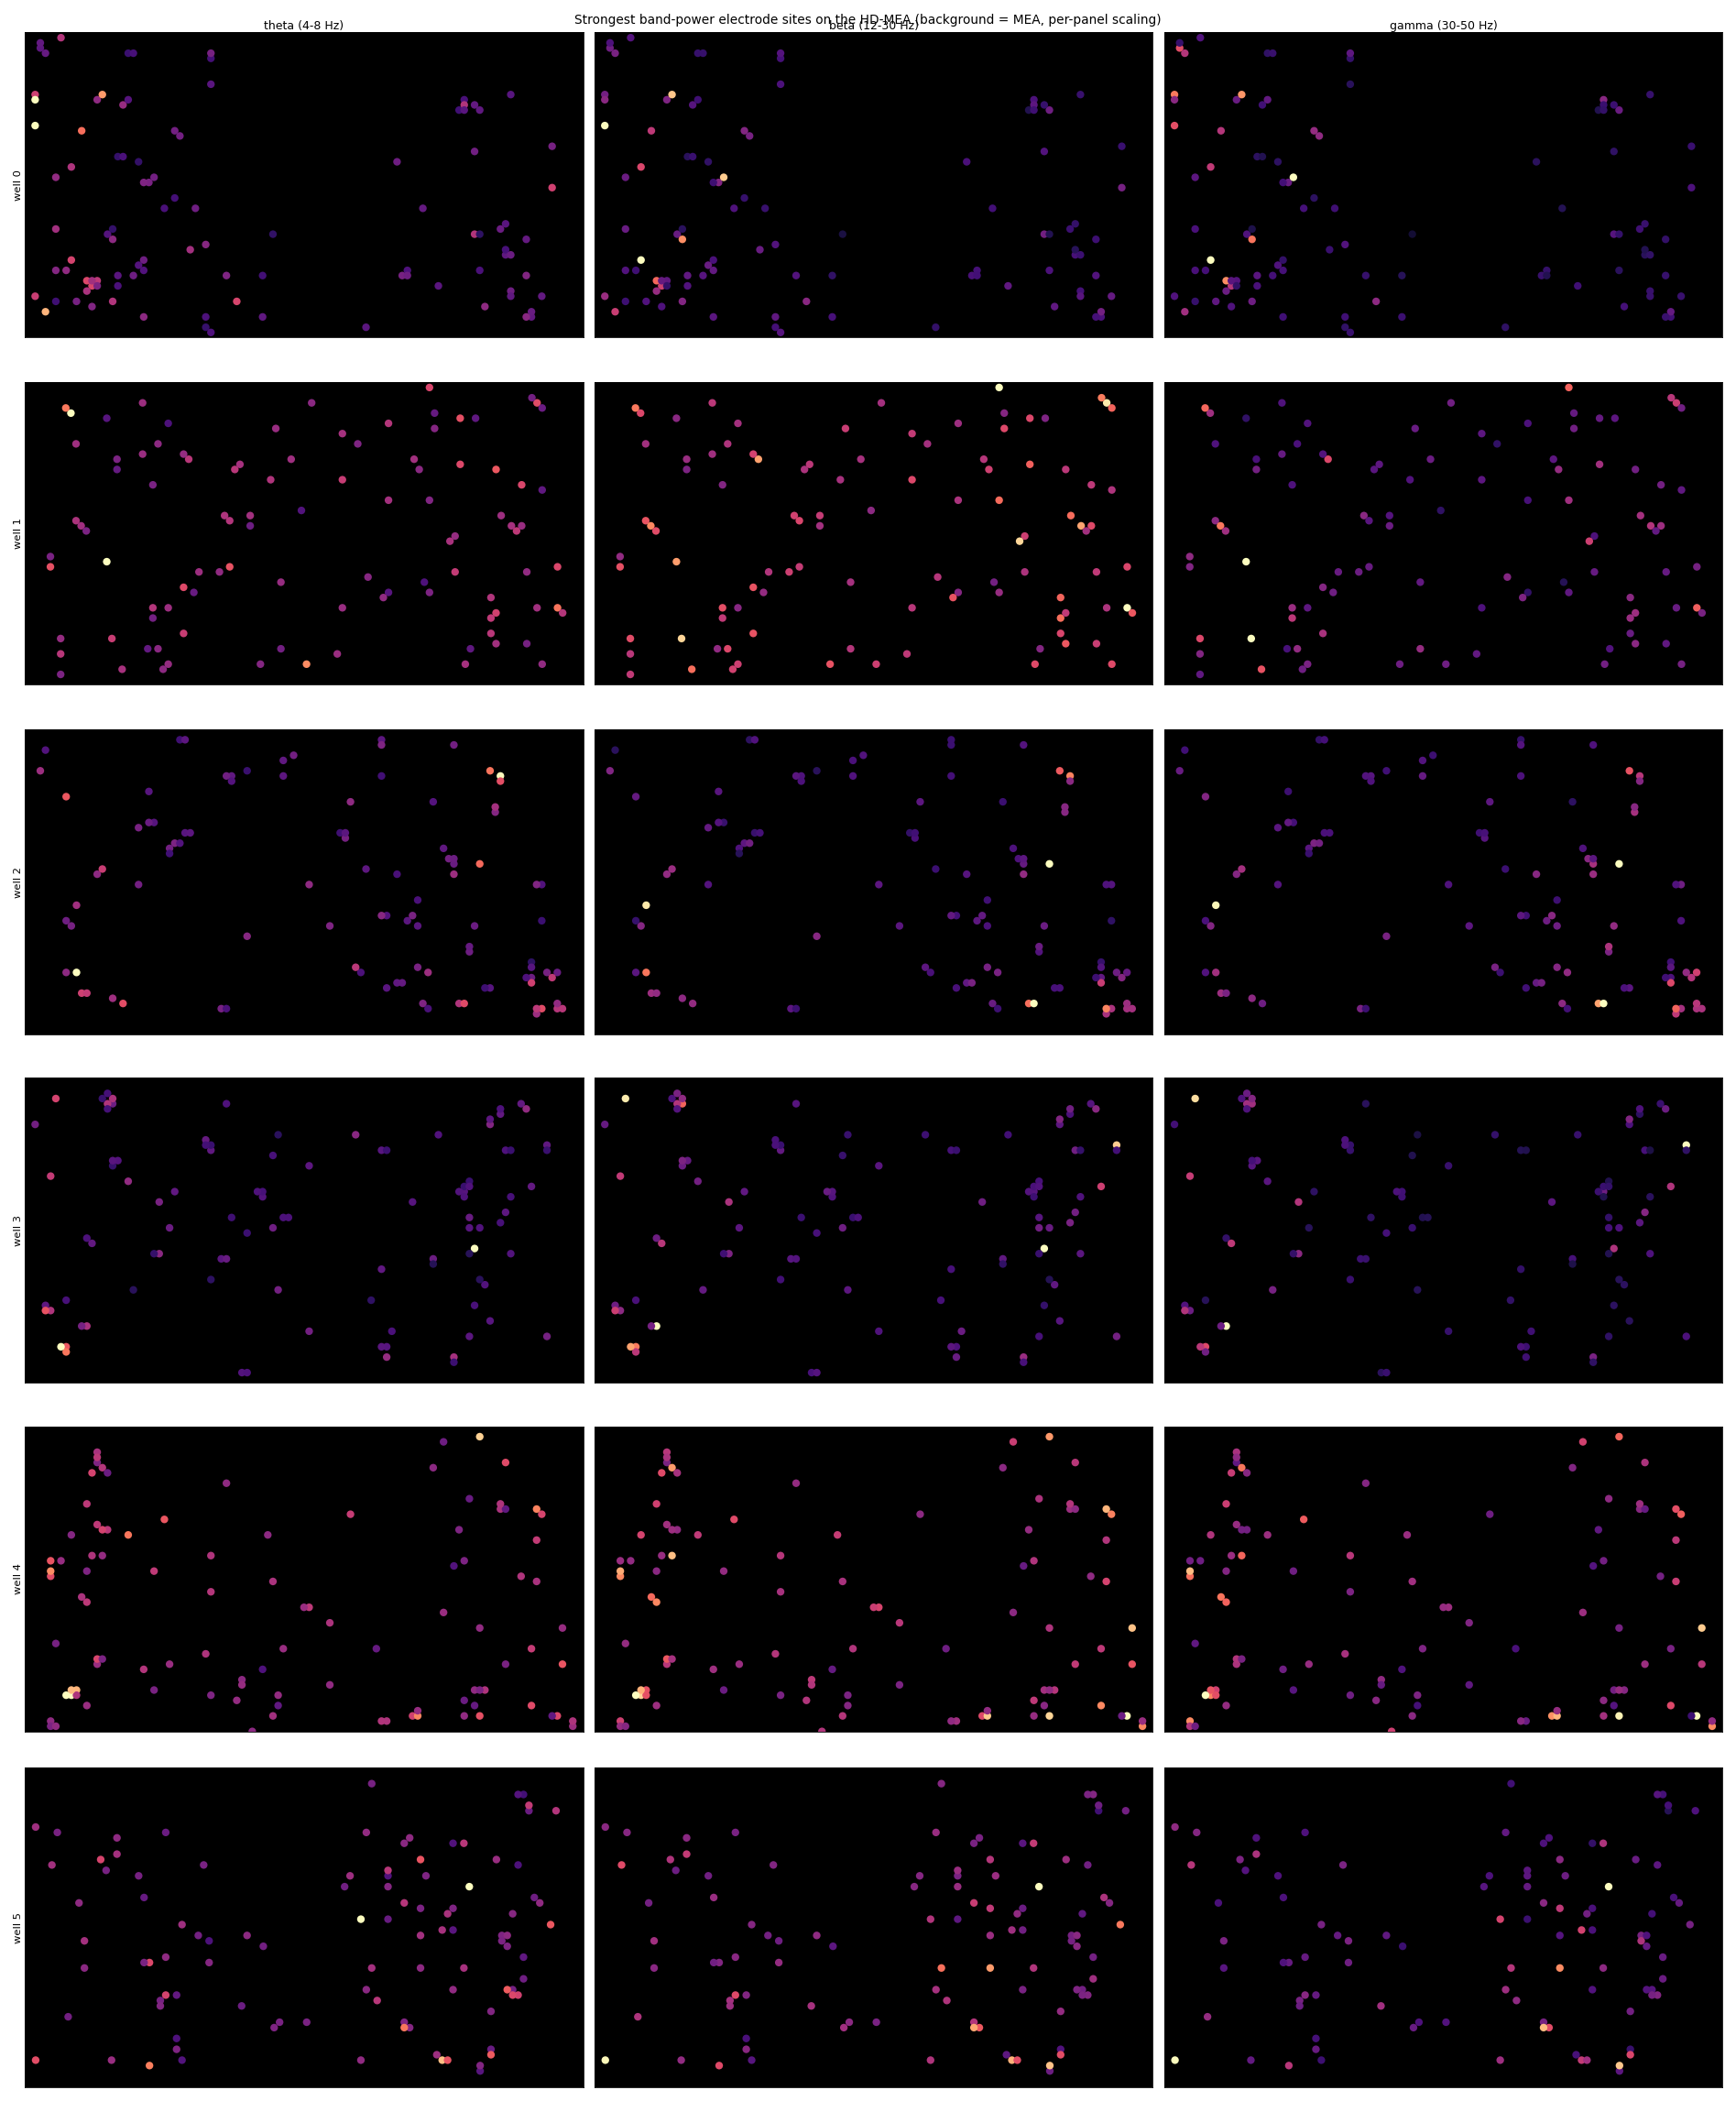

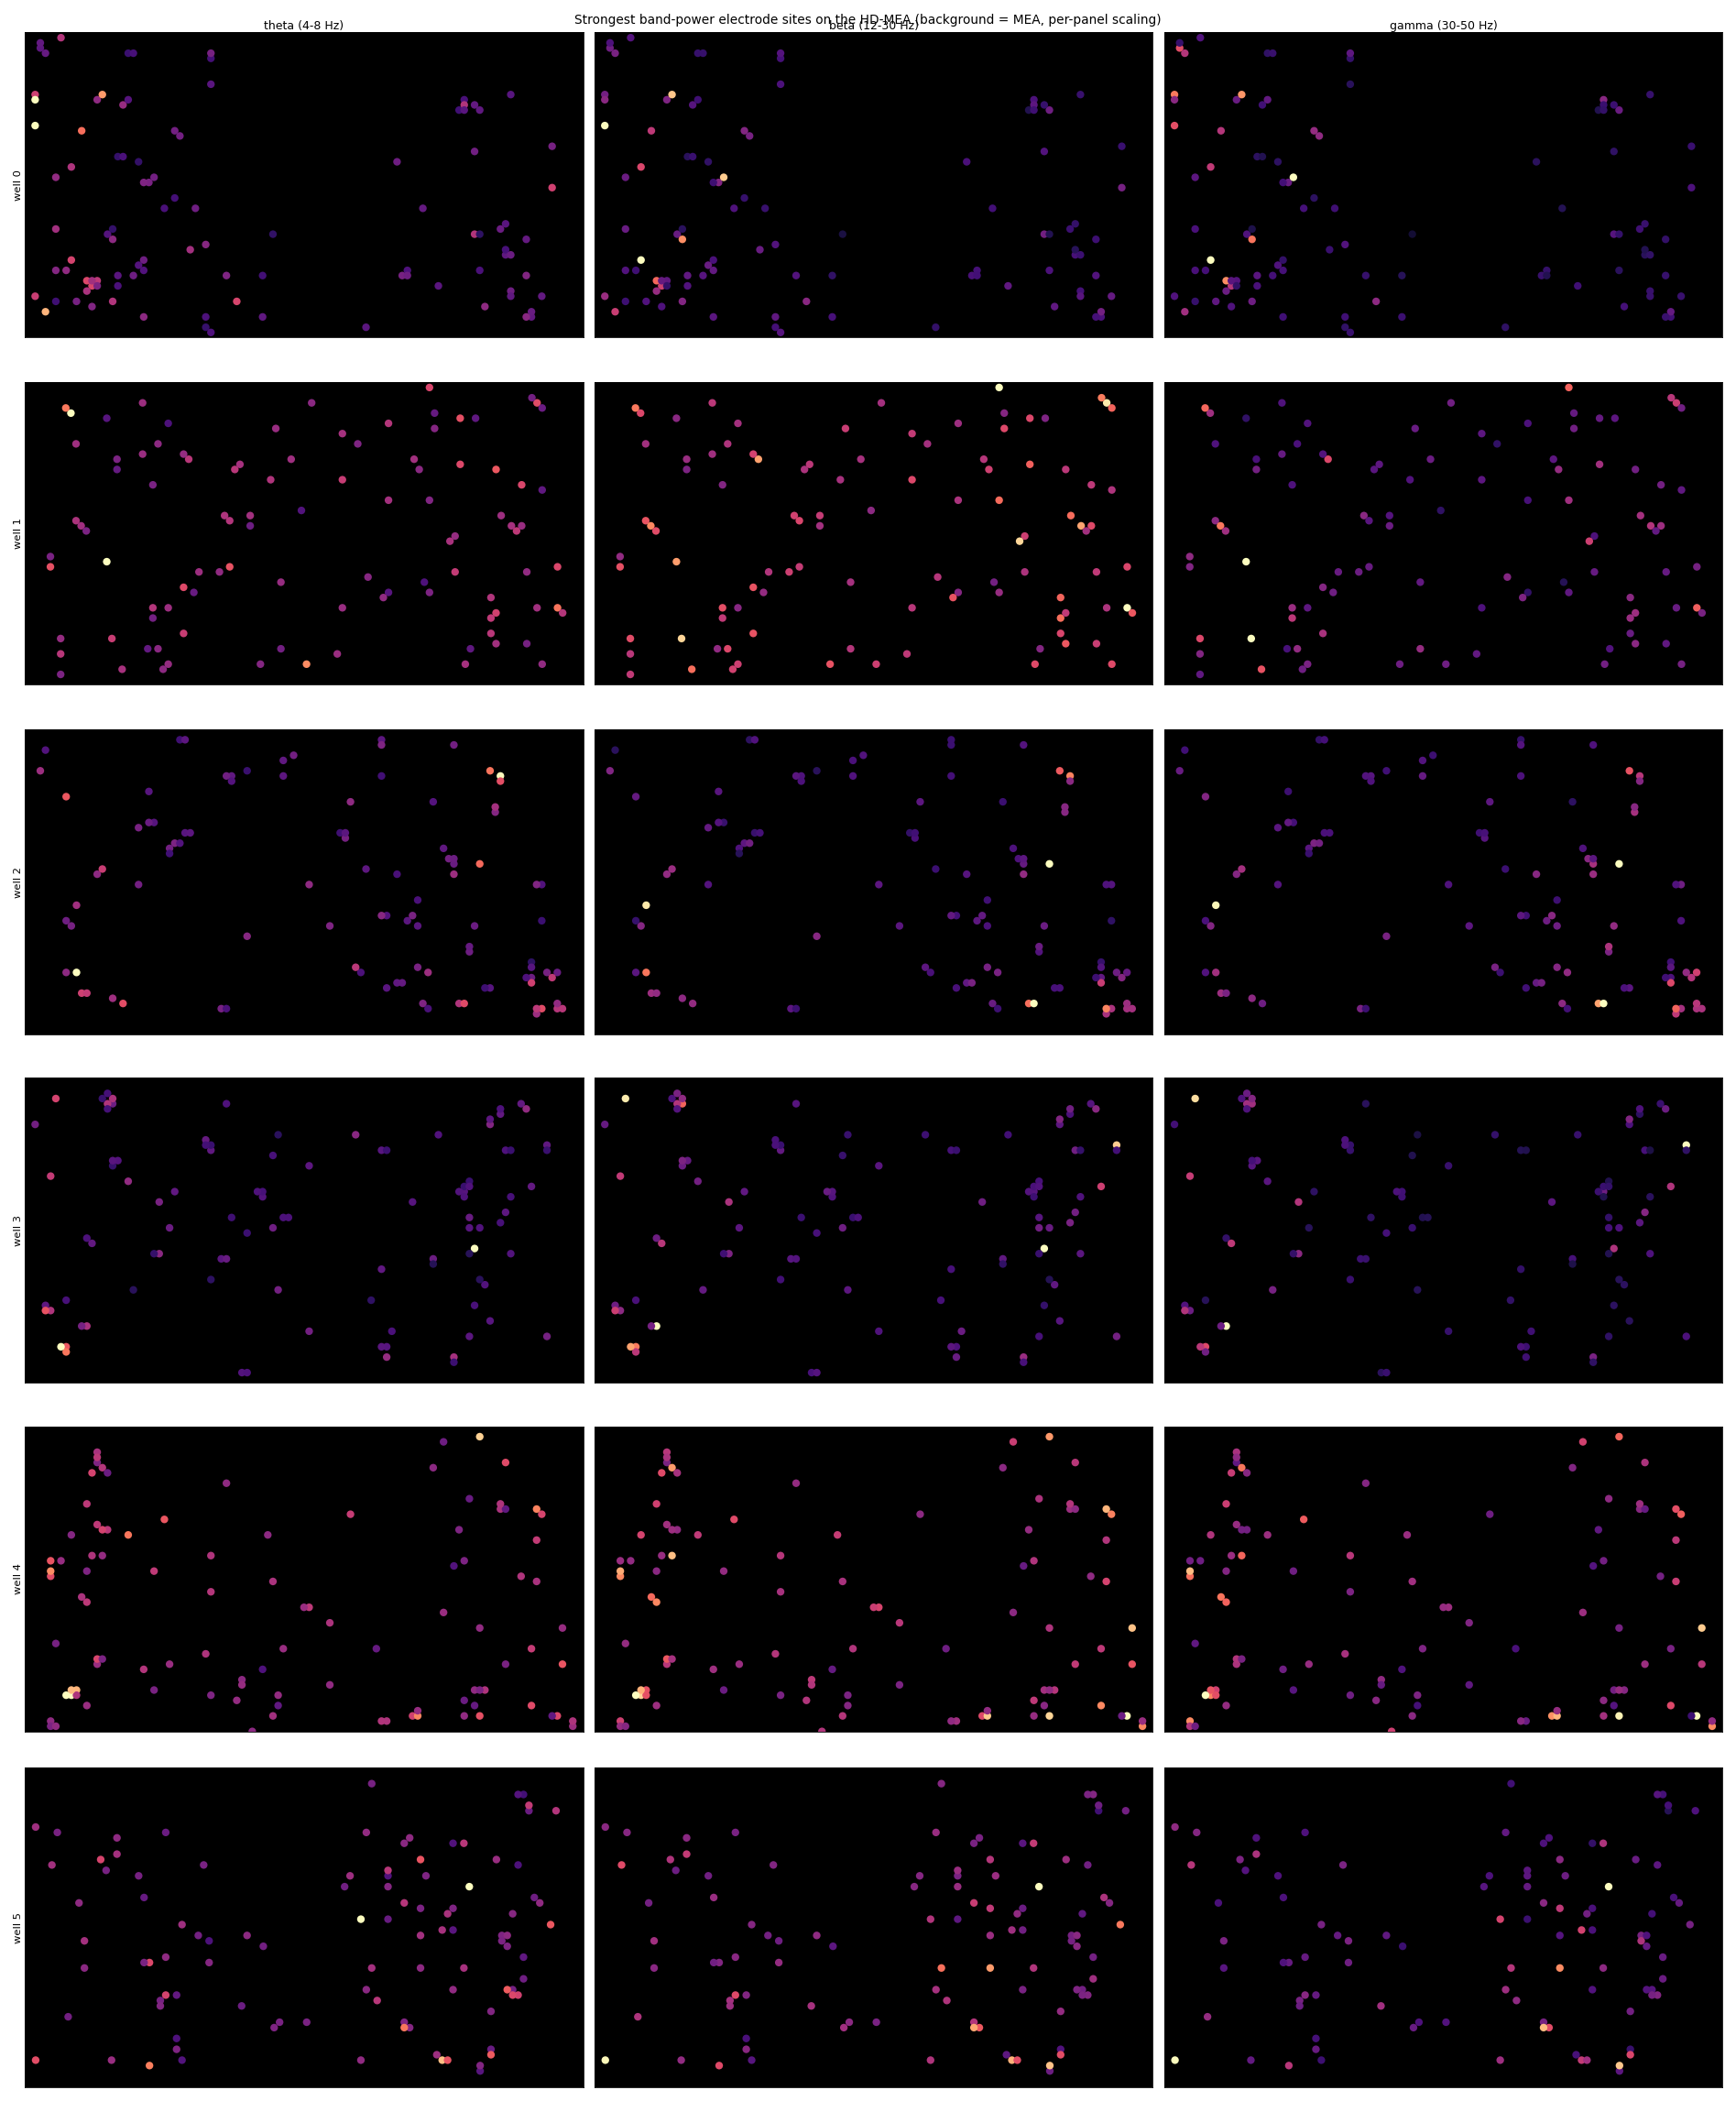

In [134]:
def plot_site_power_maps(site_band_power, contexts):
    if site_band_power.empty:
        print("No site band power to plot.")
        return None
    wells = sorted(site_band_power["well"].unique())
    bands = list(FREQUENCY_BANDS.keys())
    fig, axes = plt.subplots(len(wells), len(bands), figsize=(4.2 * len(bands), 2.6 * len(wells)), squeeze=False)
    for r, well in enumerate(wells):
        info = contexts[int(well)]["info"]
        xlim = (float(info["x_um_min"]), float(info["x_um_max"]))
        ylim = (float(info["y_um_min"]), float(info["y_um_max"]))
        for c, band in enumerate(bands):
            ax = axes[r][c]
            ax.set_facecolor("black")
            g = site_band_power[(site_band_power.well == well) & (site_band_power.band == band)]
            if not g.empty:
                p = g["power"].to_numpy(float)
                vmax = np.nanpercentile(p, 99) if np.any(np.isfinite(p)) and np.nanmax(p) > 0 else 1.0
                ax.scatter(g["x_um"], g["y_um"], c=p, s=16, cmap="magma", vmin=0.0, vmax=vmax, linewidths=0)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)
            ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                lo, hi = FREQUENCY_BANDS[band]
                ax.set_title(f"{band} ({lo:g}-{hi:g} Hz)")
            if c == 0:
                ax.set_ylabel(f"well {well}")
    fig.suptitle("Strongest band-power electrode sites on the HD-MEA (background = MEA, per-panel scaling)")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "site_band_power_maps.png", dpi=300, bbox_inches="tight")
    return fig


plot_site_power_maps(site_band_power, anchor_contexts)

## Step 9e - Rank-stratified burst-aligned power spectrograms

Average Morlet power (mean across the ref population), aligned to the snapped anchor, separately
for burst windows and time-shifted background, **stratified by nLFP-magnitude rank**. Power is
shown in dB relative to each stratum's shifted background (removes 1/f), so burst-specific
time-frequency structure stands out - e.g. a post-anchor high->low gamma drift ~one theta period
later. Comparing rank strata shows whether weaker bursts carry the same (or "echo") structure.
Separate power-only pass with its own cache; does not touch the coherence cache.

In [135]:
def _power_rel(coeffs, t_s, center, rel):
    power = np.nanmean(np.abs(coeffs) ** 2, axis=2)  # (F, T)
    grid = float(center) + rel
    out = np.empty((power.shape[0], rel.size), dtype=float)
    for fi in range(power.shape[0]):
        out[fi] = np.interp(grid, t_s, power[fi], left=np.nan, right=np.nan)
    return out


def compute_stratified_power(contexts, *, t_disp=POWERSPEC_T_DISP, strata=RANK_STRATA, shift_reps=SHIFT_REPS):
    rel = np.arange(-float(t_disp), float(t_disp) + 0.5 / COHERENCE_FS_HZ, 1.0 / COHERENCE_FS_HZ)
    labels = [f"{lo}-{hi}" for lo, hi in strata]
    acc = {}

    def add(label, cond, arr):
        key = (label, cond)
        if key not in acc:
            acc[key] = [np.zeros((WAVELET_FREQS_HZ.size, rel.size)), np.zeros((WAVELET_FREQS_HZ.size, rel.size))]
        finite = np.isfinite(arr)
        acc[key][0] += np.where(finite, arr, 0.0)
        acc[key][1] += finite

    max_rank = max(hi for _, hi in strata)
    win = 2.0 * float(t_disp) + 2.0 * float(POWERSPEC_PAD)
    for well, ctx in contexts.items():
        dataset = dataset_for_well(int(well))
        electrodes = np.asarray(ctx["refs"], dtype=int)
        bursts = ctx["bursts"]
        rng = np.random.default_rng(RANDOM_SEED + int(well))
        rec_stop = float(ctx["info"]["raw_shape"][1]) / float(ctx["info"]["fs_raw"])
        ev = bursts[bursts["nlfp_rank"] <= max_rank].sort_values("nlfp_rank")
        for row in ev.itertuples(index=False):
            rank = int(row.nlfp_rank)
            label = next((f"{lo}-{hi}" for lo, hi in strata if lo <= rank <= hi), None)
            if label is None:
                continue
            a = float(row.lfp_anchor_time_s)
            seg = load_lfp_segment(dataset, a, win, electrodes, min_channels=2)
            if seg is None:
                continue
            add(label, "burst", _power_rel(morlet_coefficients(seg["data"]), seg["t_s"], a, rel))
            for _ in range(int(shift_reps)):
                c = _random_shift_center(a, win, rec_stop, bursts, rng)
                if not np.isfinite(c):
                    continue
                segb = load_lfp_segment(dataset, c, win, electrodes, min_channels=2)
                if segb is None:
                    continue
                add(label, "shifted", _power_rel(morlet_coefficients(segb["data"]), segb["t_s"], c, rel))
        print(f"well {well}: stratified power done")
    mean = {k: np.divide(v[0], v[1], out=np.full_like(v[0], np.nan), where=v[1] > 0) for k, v in acc.items()}
    counts = {k: int(np.nanmax(v[1])) if np.any(v[1] > 0) else 0 for k, v in acc.items()}
    return {"rel_s": rel, "freq_hz": np.asarray(WAVELET_FREQS_HZ), "labels": labels, "mean": mean, "counts": counts,
            "config": {"strata": strata, "t_disp": float(t_disp), "shift_reps": int(shift_reps), "n_max": MAX_EVENTS_PER_WELL, "wells": WELLS}}


powerspec = None
if POWERSPEC_CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    with POWERSPEC_CACHE_PATH.open("rb") as fh:
        cached_ps = pickle.load(fh)
    if cached_ps.get("config", {}).get("strata") == RANK_STRATA and cached_ps["config"].get("wells") == WELLS:
        powerspec = cached_ps
        print(f"Loaded cached stratified power: {POWERSPEC_CACHE_PATH}")
if powerspec is None:
    powerspec = compute_stratified_power(anchor_contexts)
    with POWERSPEC_CACHE_PATH.open("wb") as fh:
        pickle.dump(powerspec, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved stratified power: {POWERSPEC_CACHE_PATH}")
print("strata counts:", powerspec["counts"])

Loaded cached stratified power: /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance_div12_wavelet_snapped_anchor/stratified_power_spectrograms_cache.pkl
strata counts: {('1-5', 'burst'): 30, ('1-5', 'shifted'): 90, ('6-15', 'burst'): 60, ('6-15', 'shifted'): 174, ('16-30', 'burst'): 90, ('16-30', 'shifted'): 242, ('31-50', 'burst'): 120, ('31-50', 'shifted'): 299}


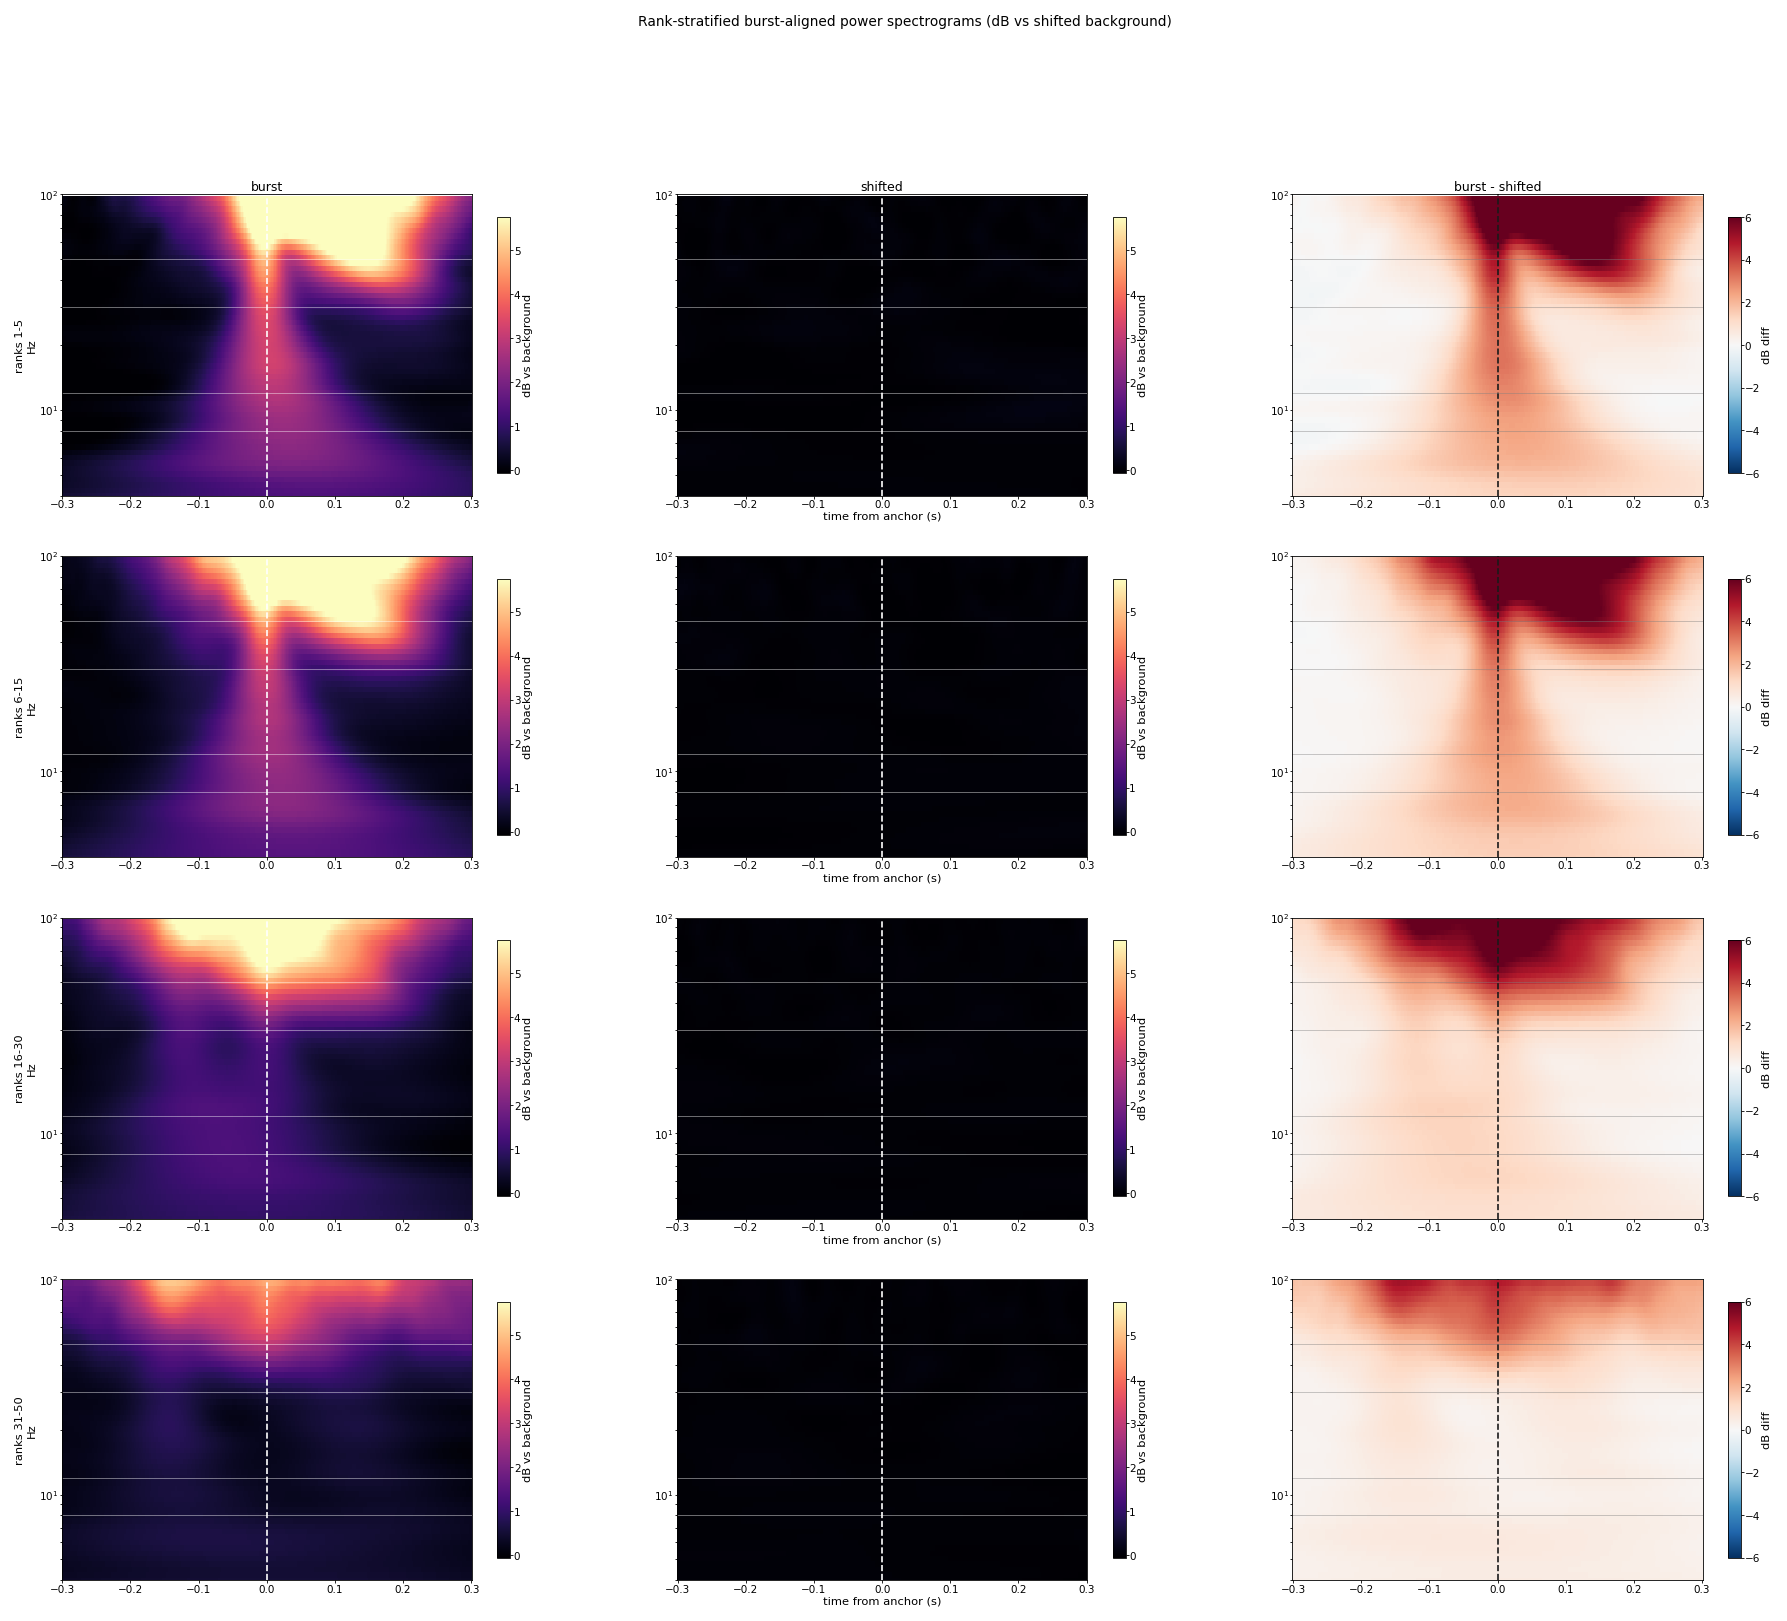

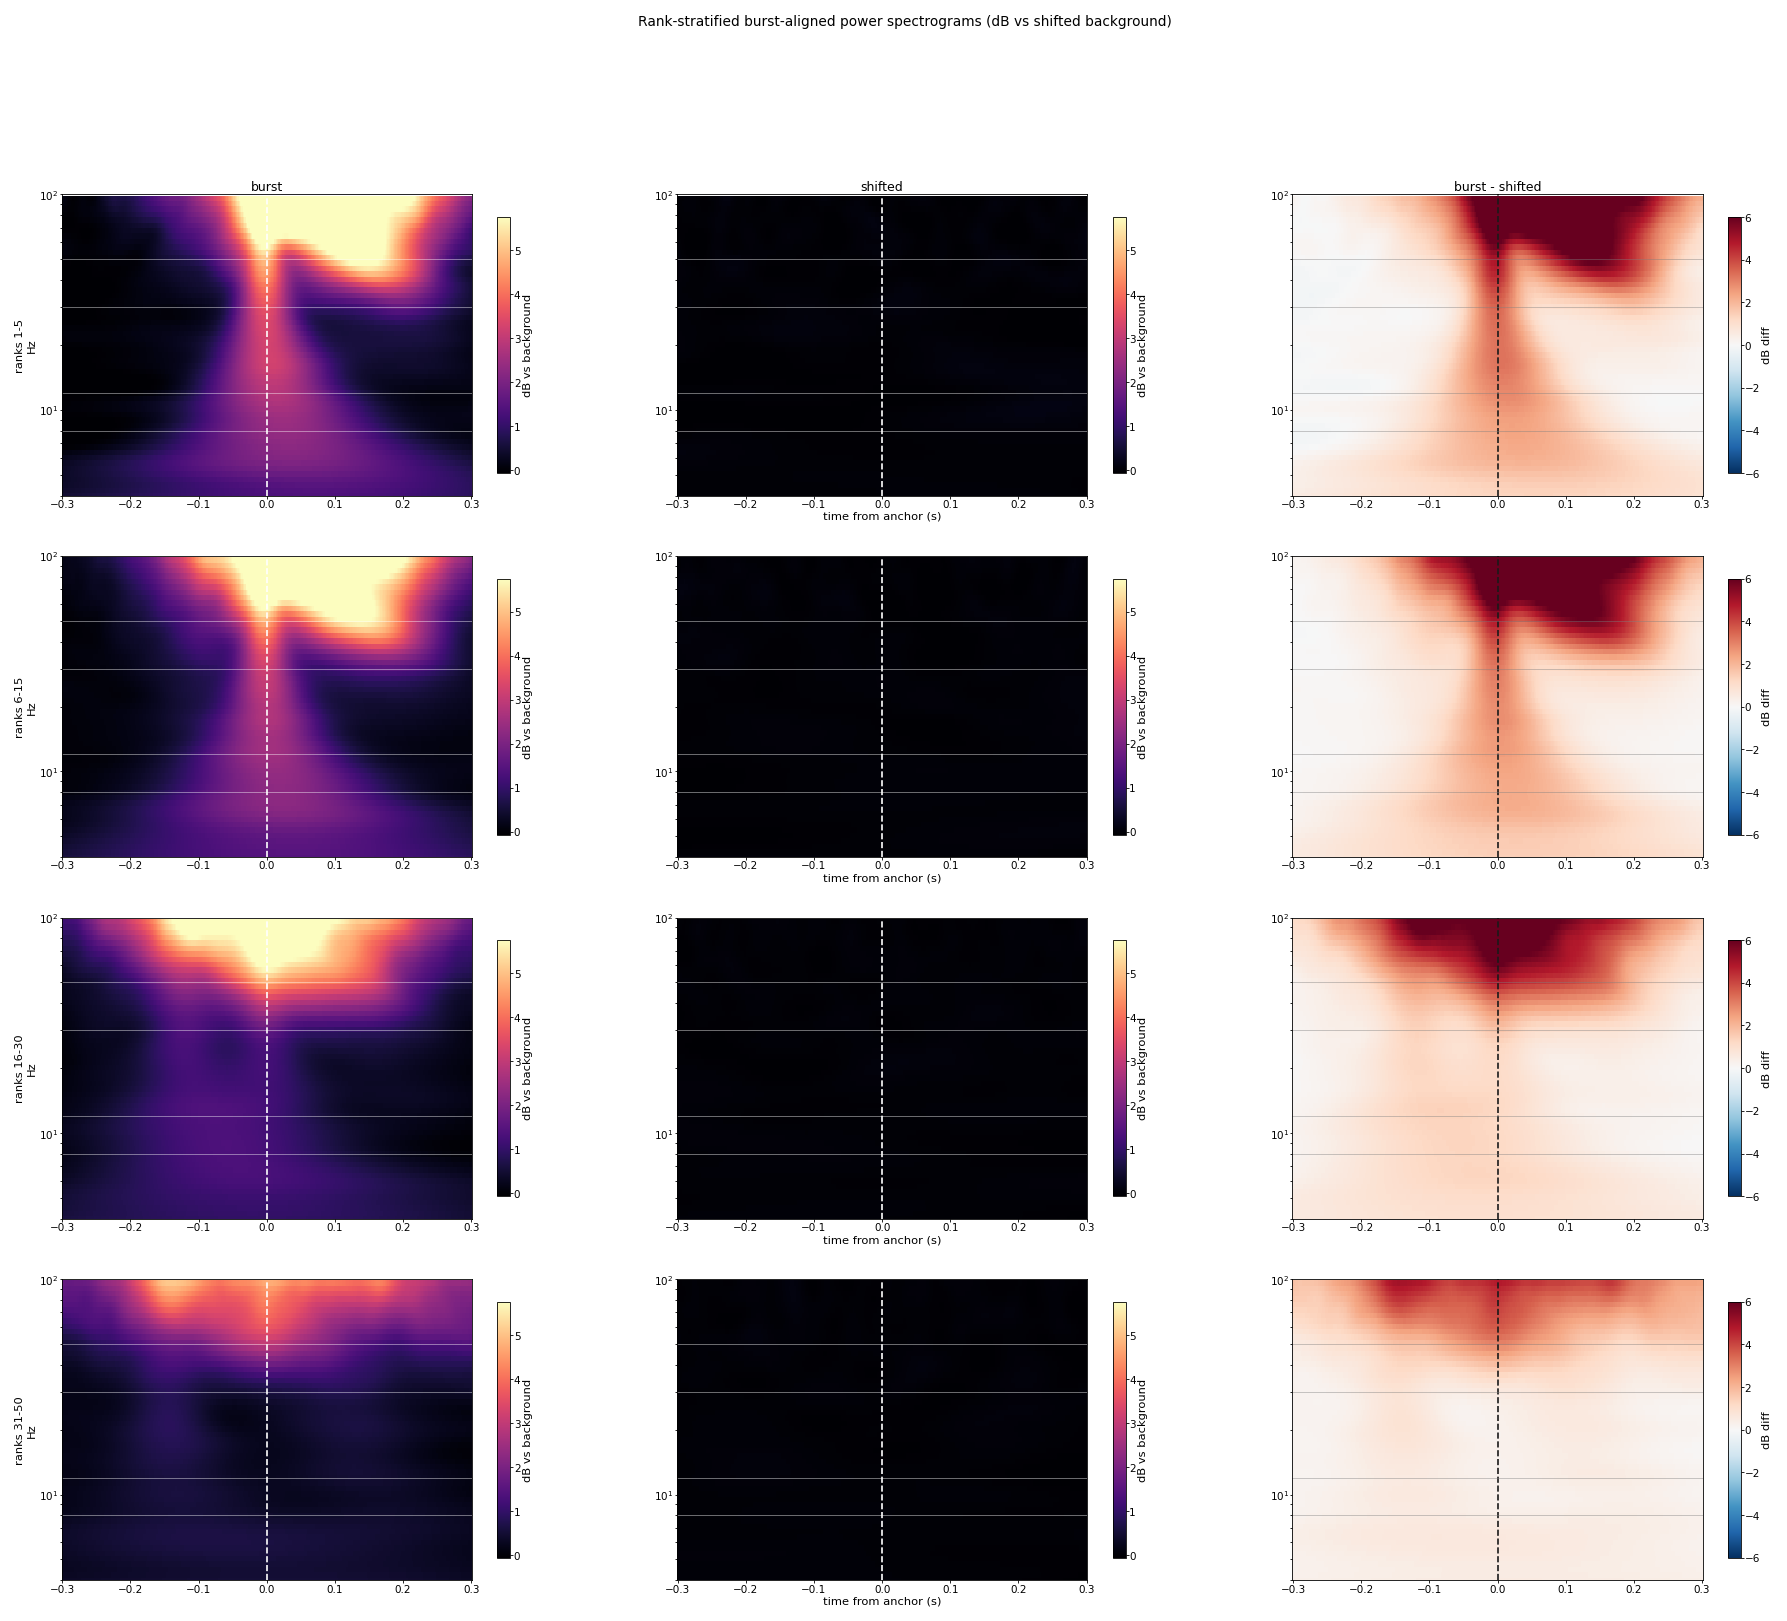

In [136]:
def plot_stratified_power(ps):
    rel, freqs, labels = ps["rel_s"], ps["freq_hz"], ps["labels"]
    tiny = np.finfo(float).tiny
    rows = [lab for lab in labels if (lab, "burst") in ps["mean"] and (lab, "shifted") in ps["mean"]]
    if not rows:
        print("No stratified power to plot.")
        return None
    fig, axes = plt.subplots(len(rows), 3, figsize=(15, 3.0 * len(rows)), squeeze=False)
    # shared dB scale for burst/shifted columns
    all_db = []
    panels = {}
    for lab in rows:
        b = ps["mean"][(lab, "burst")]; s = ps["mean"][(lab, "shifted")]
        base = np.maximum(np.nanmean(s, axis=1, keepdims=True), tiny)
        bdb = 10.0 * np.log10(np.maximum(b, tiny) / base)
        sdb = 10.0 * np.log10(np.maximum(s, tiny) / base)
        panels[lab] = (bdb, sdb, bdb - sdb)
        all_db.append(bdb); all_db.append(sdb)
    stack = np.concatenate([a.ravel() for a in all_db])
    vmin, vmax = np.nanpercentile(stack, [2, 98])
    for r, lab in enumerate(rows):
        bdb, sdb, diff = panels[lab]
        for c, (M, title, cmap, lim) in enumerate([(bdb, "burst", "magma", None), (sdb, "shifted", "magma", None), (diff, "burst - shifted", "RdBu_r", 6.0)]):
            ax = axes[r][c]
            if lim is None:
                im = ax.pcolormesh(rel, freqs, M, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
            else:
                im = ax.pcolormesh(rel, freqs, M, shading="auto", cmap=cmap, vmin=-lim, vmax=lim)
            ax.axvline(0.0, color=("0.1" if c == 2 else "white"), lw=0.8, ls="--")
            for bnd in (8.0, 12.0, 30.0, 50.0):
                ax.axhline(bnd, color=("0.5" if c == 2 else "white"), lw=0.4, alpha=0.5)
            ax.set_yscale("log"); ax.set_ylim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
            if r == 0:
                ax.set_title(title)
            if c == 0:
                ax.set_ylabel(f"ranks {lab}\nHz")
            fig.colorbar(im, ax=ax, shrink=0.85, label=("dB vs background" if c < 2 else "dB diff"))
        axes[r][1].set_xlabel("time from anchor (s)")
    fig.suptitle("Rank-stratified burst-aligned power spectrograms (dB vs shifted background)")
    fig.savefig(FIGURE_DIR / "stratified_power_spectrograms.png", dpi=300, bbox_inches="tight")
    return fig


plot_stratified_power(powerspec)

## Step 9f - 1/f-corrected burst power spectrum

Burst LFP power excess over the time-shifted background (dB), time-averaged in a peri-anchor
window, per rank stratum and pooled. Removing the background removes 1/f, so a genuine narrowband
oscillator would appear as a bump. The dashed line marks the population IFR peak frequency.

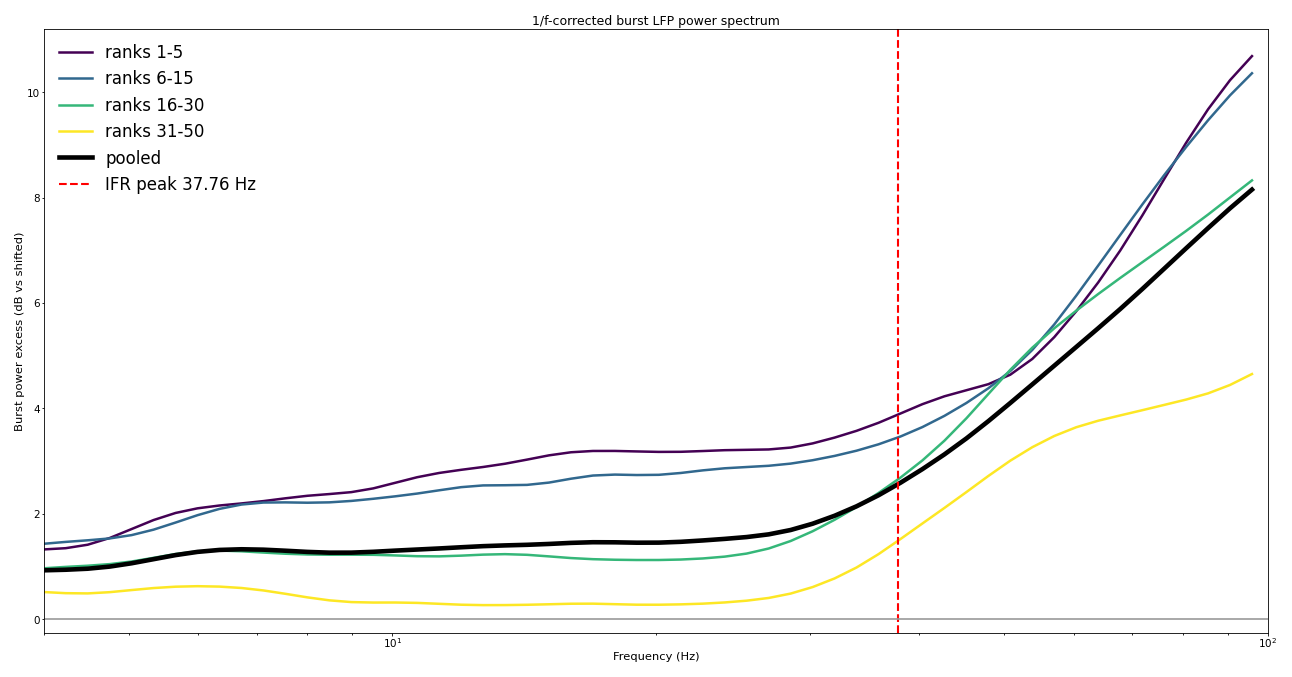

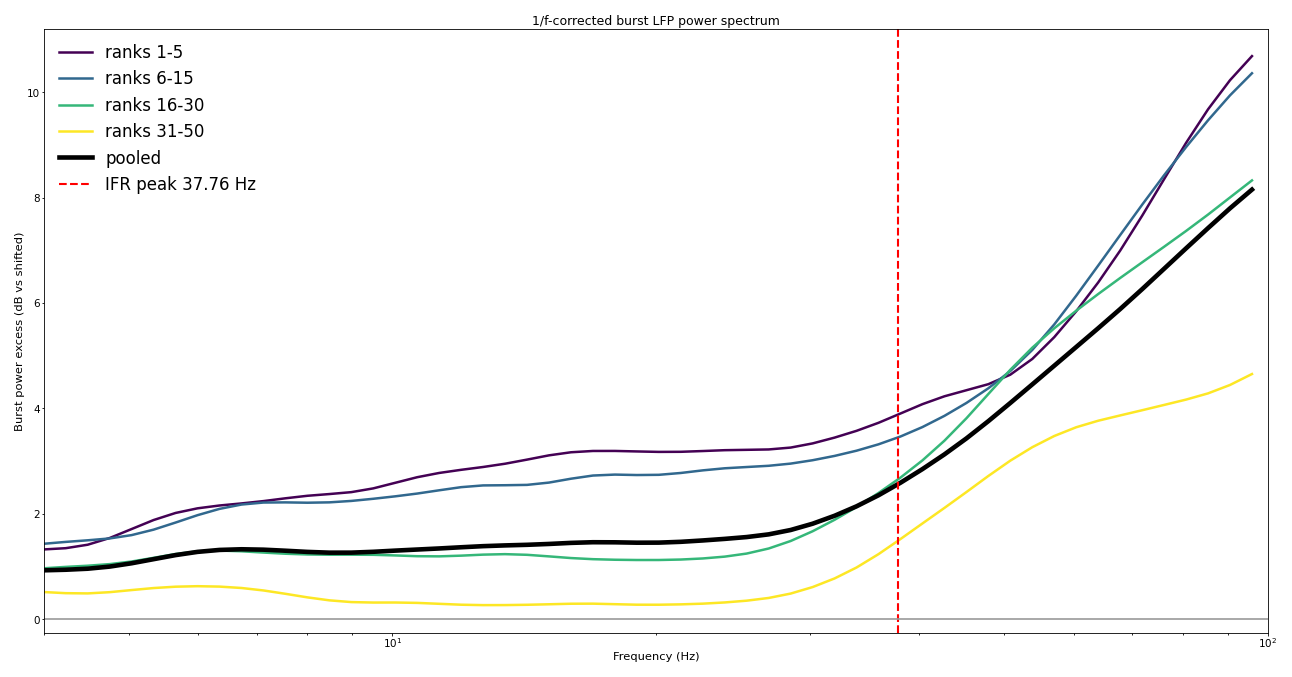

In [137]:
def plot_power_spectrum_1f(ps, peak_ms=POWERSPEC_PEAK_MS):
    tiny = np.finfo(float).tiny
    rel, f, labels = ps["rel_s"], ps["freq_hz"], ps["labels"]
    near = (rel >= -peak_ms / 1000.0) & (rel <= peak_ms / 1000.0)
    cmap = plt.get_cmap("viridis")
    fig, ax = plt.subplots(figsize=(8.5, 4.4), constrained_layout=True)
    bsum = ssum = None; wsum = 0.0
    for i, lab in enumerate(labels):
        b = ps["mean"].get((lab, "burst")); s = ps["mean"].get((lab, "shifted"))
        if b is None or s is None:
            continue
        bm = np.nanmean(b[:, near], axis=1); sm = np.nanmean(s[:, near], axis=1)
        ax.plot(f, 10.0 * np.log10(np.maximum(bm, tiny) / np.maximum(sm, tiny)),
                color=cmap(i / max(1, len(labels) - 1)), lw=1.2, label=f"ranks {lab}")
        c = float(ps["counts"].get((lab, "burst"), 0))
        bsum = bm * c if bsum is None else bsum + bm * c
        ssum = sm * c if ssum is None else ssum + sm * c
        wsum += c
    if wsum > 0:
        ax.plot(f, 10.0 * np.log10(np.maximum(bsum / wsum, tiny) / np.maximum(ssum / wsum, tiny)),
                color="black", lw=2.2, label="pooled")
    ax.axvline(IFR_PEAK_HZ, color="red", lw=1.0, ls="--", label=f"IFR peak {IFR_PEAK_HZ:g} Hz")
    ax.axhline(0.0, color="0.6", lw=0.8)
    ax.set_xscale("log"); ax.set_xlim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
    ax.set(xlabel="Frequency (Hz)", ylabel="Burst power excess (dB vs shifted)",
           title="1/f-corrected burst LFP power spectrum")
    ax.legend(frameon=False, fontsize=8)
    fig.savefig(FIGURE_DIR / "burst_power_spectrum_1f_corrected.png", dpi=300, bbox_inches="tight")
    return fig


plot_power_spectrum_1f(powerspec)

## Step 9g - Spike-field phase locking per Morlet suboctave

For each Morlet suboctave frequency, how strongly do spikes lock to the *local* LFP phase (spike on
electrode e vs LFP phase on e at that frequency). Locking is the **pairwise phase consistency**
(PPC, unbiased by spike count) per electrode, averaged across electrodes; a sample-shuffled null is
shown for reference. The peak of the PPC spectrum is the suboctave spikes prefer - a sharper readout
than a fixed 30-50 Hz band. Separate pass (loads spikes + LFP), own cache.

well 0: spike-field locking done
well 1: spike-field locking done
well 2: spike-field locking done
well 3: spike-field locking done
well 4: spike-field locking done
well 5: spike-field locking done
Saved spike-field locking: /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance_div12_wavelet_snapped_anchor/spike_field_locking_cache.pkl
removed: PPC peak at 95.9 Hz (=0.015)
distant: PPC peak at 5.3 Hz (=0.039)


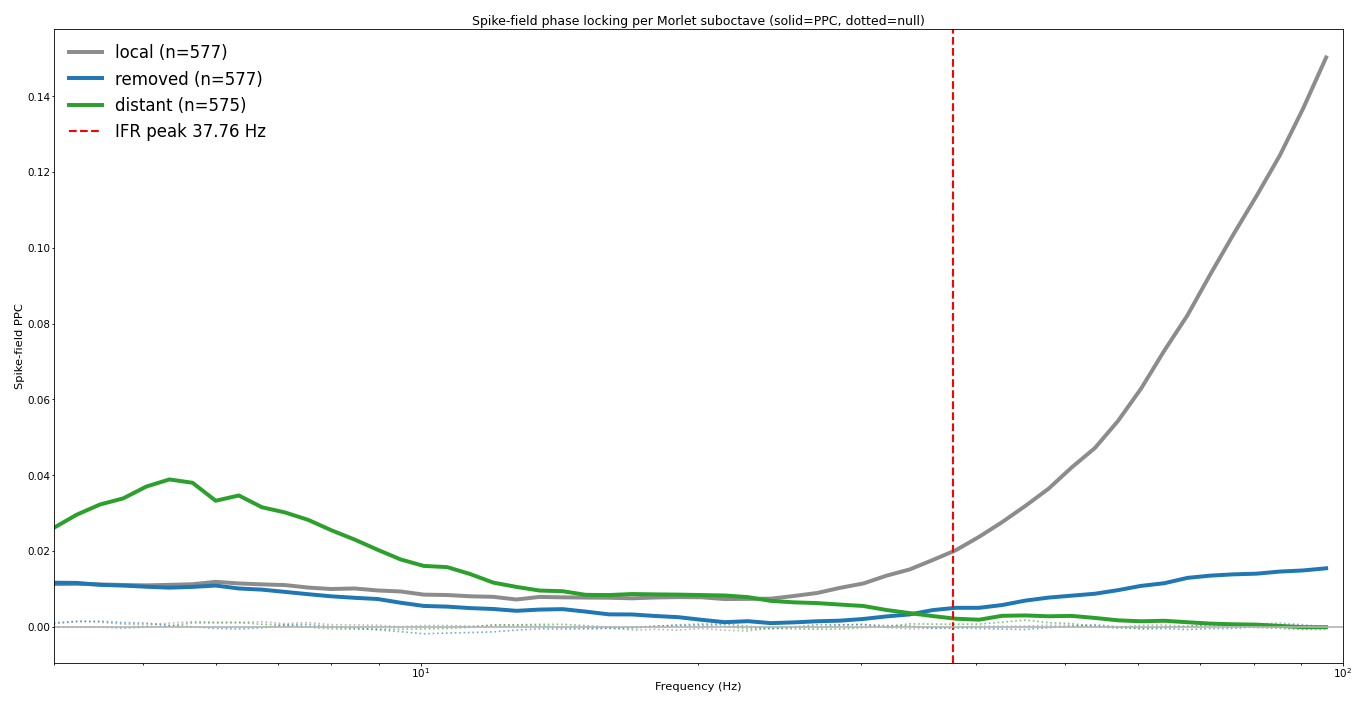

In [138]:
def _sf_accumulate(store, store_null, ts, coeff_ft, t_s, n_t, rng, shuffle, phase_hist=None, phase_edges=None):
    # coeff_ft: (F, T) complex field channel to lock to; ts: spike times. Interpolated phase.
    nf = coeff_ft.shape[0]
    re = np.array([np.interp(ts, t_s, coeff_ft[k].real) for k in range(nf)])
    im = np.array([np.interp(ts, t_s, coeff_ft[k].imag) for k in range(nf)])
    z = re + 1j * im
    u = z / np.where(np.abs(z) > 0, np.abs(z), 1.0)
    store[0] += u.sum(axis=1); store[1] += ts.size
    if phase_hist is not None:
        bins = np.clip(np.digitize(np.angle(u), phase_edges) - 1, 0, phase_hist.shape[1] - 1)  # (F, n)
        for k in range(nf):
            np.add.at(phase_hist[k], bins[k], 1.0)
    if shuffle:
        zn = coeff_ft[:, rng.integers(0, n_t, size=ts.size)]
        store_null += (zn / np.where(np.abs(zn) > 0, np.abs(zn), 1.0)).sum(axis=1)


def _spike_remove_raw(raw, fs_raw, t0, electrodes_loaded, elec_times, w0, w1, half_ms):
    out = raw.astype(np.float64, copy=True)
    half = max(1, int(round(half_ms * 1e-3 * fs_raw)))
    n = raw.shape[0]
    for ci, e in enumerate(electrodes_loaded):
        ts = elec_times.get(int(e))
        if ts is None:
            continue
        ts = ts[(ts >= w0) & (ts <= w1)]
        if ts.size == 0:
            continue
        bad = np.zeros(n, dtype=bool)
        for i in np.round((ts - t0) * fs_raw).astype(int):
            bad[max(0, i - half):min(n, i + half + 1)] = True
        good = ~bad
        if good.sum() >= 2:
            out[bad, ci] = np.interp(np.flatnonzero(bad), np.flatnonzero(good), out[good, ci])
    return out.astype(np.float32)


def compute_spike_field_locking(contexts, *, min_spikes=SF_MIN_SPIKES, shuffle=SF_SHUFFLE):
    nf = WAVELET_FREQS_HZ.size
    metrics = ["local", "removed", "distant"]
    S = {m: {} for m in metrics}; Snull = {m: {} for m in metrics}
    edges, centers = distance_edges_and_centers()
    dist_sum = np.zeros((centers.size, nf)); dist_cnt = np.zeros(centers.size)  # distance-resolved (other-electrode) PPC
    phase_edges = np.linspace(-np.pi, np.pi, int(SF_PHASE_BINS) + 1)
    phase_centers = 0.5 * (phase_edges[:-1] + phase_edges[1:])
    phase_hist = {"local": np.zeros((nf, int(SF_PHASE_BINS))), "removed": np.zeros((nf, int(SF_PHASE_BINS)))}  # figure-3 style spike-phase distributions
    rng = np.random.default_rng(RANDOM_SEED)
    for well, ctx in contexts.items():
        dataset = dataset_for_well(int(well))
        spikes, _, _ = load_data_store_spikes(RAW_LFP_FILE, dataset, min_amp=MIN_AMP)
        st = np.asarray(spikes["time"], float); se = np.asarray(spikes["electrode"], int)
        elec_times = {int(e): np.sort(st[se == int(e)]) for e in ctx["refs"] if np.any(se == int(e))}
        electrodes = np.asarray(ctx["refs"], int)
        info = inspect_file(RAW_LFP_FILE, dataset); fsr = float(info["fs_raw"]); stop = info["raw_shape"][1] / fsr
        Rpair = {}; Npair = {}; coords_well = None  # per-well spike(e)->field(all j) resultants for distance binning
        for row in select_events_for_well(ctx).itertuples(index=False):
            w0, w1 = float(row.start_time_s), float(row.end_time_s)
            win = (w1 - w0) + 2.0 * WAVELET_PAD_S; c = 0.5 * (w0 + w1)
            s0, s1 = c - win / 2.0, c + win / 2.0
            if s0 < 0 or s1 > stop:
                continue
            ct = _channels_for_electrodes(dataset, electrodes)
            if len(ct) < 2:
                continue
            raw, coords_mm, fsl, mp = load_chunk(RAW_LFP_FILE, dataset, int(round(s0 * fsr)), max(1, int(round((s1 - s0) * fsr))), channels=ct["channel"].to_numpy(int))
            if raw.shape[0] < 8 or raw.shape[1] < 2:
                continue
            elec_loaded = np.asarray(mp["electrode"], int)
            if coords_well is None:
                coords_well = np.asarray(coords_mm, float) * 1000.0  # um, aligned to channel order
            data = bandpass_downsample(raw, fsl, COHERENCE_FILTER_LOW_HZ, COHERENCE_FILTER_HIGH_HZ, COHERENCE_FS_HZ, max_channels_per_block=128)
            t_ds = s0 + np.arange(data.shape[0]) / COHERENCE_FS_HZ; n_t = data.shape[0]
            C = morlet_coefficients(data)
            data_rm = bandpass_downsample(_spike_remove_raw(raw, fsl, s0, elec_loaded, elec_times, w0, w1, SPIKE_REMOVE_MS),
                                          fsl, COHERENCE_FILTER_LOW_HZ, COHERENCE_FILTER_HIGH_HZ, COHERENCE_FS_HZ, max_channels_per_block=128)
            C_rm = morlet_coefficients(data_rm)
            wm = (t_ds >= w0) & (t_ds <= w1)
            ref_idx = largest_nlfp_reference(data[wm] if np.any(wm) else data)
            for ci, e in enumerate(elec_loaded):
                ts = elec_times.get(int(e))
                if ts is None:
                    continue
                ts = ts[(ts >= w0) & (ts <= w1)]
                if ts.size == 0:
                    continue
                fields = [("local", C[:, :, ci]), ("removed", C_rm[:, :, ci])]
                if ref_idx is not None and ci != ref_idx:
                    fields.append(("distant", C[:, :, ref_idx]))
                for metric, coeff in fields:
                    key = (int(well), int(e))
                    if key not in S[metric]:
                        S[metric][key] = [np.zeros(nf, complex), 0]; Snull[metric][key] = np.zeros(nf, complex)
                    ph = phase_hist.get(metric)
                    _sf_accumulate(S[metric][key], Snull[metric][key], ts, coeff, t_ds, n_t, rng, shuffle,
                                   phase_hist=ph, phase_edges=(phase_edges if ph is not None else None))
                # distance-resolved: lock spikes on ci to the field at ALL channels (nearest sample; bleed-free for far j)
                idxs = np.clip(np.round((ts - s0) * COHERENCE_FS_HZ).astype(int), 0, n_t - 1)
                Uf = C[:, idxs, :]
                Uf = Uf / np.where(np.abs(Uf) > 0, np.abs(Uf), 1.0)  # (F, n, nch)
                if ci not in Rpair:
                    Rpair[ci] = np.zeros((nf, C.shape[2]), complex); Npair[ci] = 0
                Rpair[ci] += Uf.sum(axis=1); Npair[ci] += idxs.size
        # reduce this well's pairs into radial-distance bins (PPC magnitudes averaged -> no phase-offset washout)
        if coords_well is not None:
            for ci_e, R in Rpair.items():
                n = Npair[ci_e]
                if n < min_spikes:
                    continue
                ppc_j = (np.abs(R) ** 2 - n) / (n * (n - 1))  # (F, nch)
                d = np.sqrt(np.sum((coords_well - coords_well[ci_e]) ** 2, axis=1))
                b = np.searchsorted(edges, d, side="right") - 1
                for j in range(coords_well.shape[0]):
                    if j == ci_e or d[j] < SF_BLEED_EXCLUDE_UM or b[j] < 0 or b[j] >= centers.size:
                        continue
                    dist_sum[b[j]] += ppc_j[:, j]; dist_cnt[b[j]] += 1
        print(f"well {well}: spike-field locking done")

    def ppc_of(store, snull=None):
        out = []
        for key, (Sv, n) in store.items():
            if n >= min_spikes:
                vec = snull[key] if snull is not None else Sv
                out.append((np.abs(vec) ** 2 - n) / (n * (n - 1)))
        return (np.nanmean(out, axis=0), len(out)) if out else (np.full(nf, np.nan), 0)

    def rayleigh_per_well(store):
        # figure-3 style: pool spike resultants across electrodes within each well -> R = |sum|/N, z=N R^2, p=exp(-z)
        per_well = {}
        for (w, e), (Sv, n) in store.items():
            if w not in per_well:
                per_well[w] = [np.zeros(nf, complex), 0]
            per_well[w][0] += Sv; per_well[w][1] += n
        R = []; P = []
        for w, (Sv, n) in per_well.items():
            if n <= 1:
                continue
            r = np.abs(Sv) / n; zz = n * r * r
            R.append(r); P.append(np.where(zz > 745.0, 0.0, np.exp(-zz)))
        if not R:
            return np.full(nf, np.nan), np.full(nf, np.nan), 0
        R = np.asarray(R); P = np.asarray(P)
        return np.nanmean(R, axis=0), np.nanmean((P < 0.05).astype(float), axis=0), R.shape[0]

    res = {"freq_hz": np.asarray(WAVELET_FREQS_HZ), "metrics": metrics, "phase_centers": phase_centers,
           "config": {"min_spikes": min_spikes, "n_max": MAX_EVENTS_PER_WELL, "wells": WELLS,
                      "spike_remove_ms": SPIKE_REMOVE_MS, "bleed_exclude_um": SF_BLEED_EXCLUDE_UM, "phase_bins": int(SF_PHASE_BINS)}}
    for m in metrics:
        ppc, ne = ppc_of(S[m]); res[m] = {"ppc": ppc, "ppc_null": ppc_of(S[m], Snull[m])[0], "n_electrodes": ne}
    for m in ("local", "removed"):
        Rm, frac_sig, n_w = rayleigh_per_well(S[m])
        res[m]["rayleigh_R"] = Rm; res[m]["rayleigh_frac_sig"] = frac_sig; res[m]["rayleigh_n_wells"] = n_w
        res[m]["phase_hist"] = phase_hist[m]
    res["distance_resolved"] = {
        "dist_centers_um": centers, "freq_hz": np.asarray(WAVELET_FREQS_HZ),
        "ppc": np.divide(dist_sum, dist_cnt[:, None], out=np.full_like(dist_sum, np.nan), where=dist_cnt[:, None] > 0),
        "n_pairs": dist_cnt,
    }
    return res


spikefield = None
if SPIKEFIELD_CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    with SPIKEFIELD_CACHE_PATH.open("rb") as fh:
        cached_sf = pickle.load(fh)
    cfg = cached_sf.get("config", {})
    if (cfg.get("wells") == WELLS and cfg.get("n_max") == MAX_EVENTS_PER_WELL and cfg.get("spike_remove_ms") == SPIKE_REMOVE_MS
            and cfg.get("bleed_exclude_um") == SF_BLEED_EXCLUDE_UM and cfg.get("phase_bins") == int(SF_PHASE_BINS)
            and "distance_resolved" in cached_sf and "rayleigh_R" in cached_sf.get("local", {})):
        spikefield = cached_sf
        print(f"Loaded cached spike-field locking: {SPIKEFIELD_CACHE_PATH}")
if spikefield is None:
    spikefield = compute_spike_field_locking(anchor_contexts)
    with SPIKEFIELD_CACHE_PATH.open("wb") as fh:
        pickle.dump(spikefield, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved spike-field locking: {SPIKEFIELD_CACHE_PATH}")

f = spikefield["freq_hz"]
colors = {"local": "0.55", "removed": "tab:blue", "distant": "tab:green"}
fig, ax = plt.subplots(figsize=(9.0, 4.6), constrained_layout=True)
for m in spikefield["metrics"]:
    d = spikefield[m]
    if not np.any(np.isfinite(d["ppc"])):
        continue
    ax.plot(f, d["ppc"], color=colors[m], lw=1.9, label=f"{m} (n={d['n_electrodes']})")
    ax.plot(f, d["ppc_null"], color=colors[m], lw=0.8, ls=":", alpha=0.6)
for m in ("removed", "distant"):
    p = spikefield[m]["ppc"]
    if np.any(np.isfinite(p)):
        print(f"{m}: PPC peak at {f[int(np.nanargmax(p))]:.1f} Hz (={np.nanmax(p):.3f})")
ax.axvline(IFR_PEAK_HZ, color="red", lw=1.0, ls="--", label=f"IFR peak {IFR_PEAK_HZ:g} Hz")
ax.axhline(0.0, color="0.7", lw=0.8)
ax.set_xscale("log"); ax.set_xlim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
ax.set(xlabel="Frequency (Hz)", ylabel="Spike-field PPC", title="Spike-field phase locking per Morlet suboctave (solid=PPC, dotted=null)")
ax.legend(frameon=False, fontsize=8)
fig.savefig(FIGURE_DIR / "spike_field_locking_spectrum.png", dpi=300, bbox_inches="tight")

### Distance-resolved spike-field locking

Spikes on electrode e locked to the field at every OTHER electrode j (bleed-free for j beyond
`SF_BLEED_EXCLUDE_UM`), PPC averaged within radial-distance bins. PPC magnitudes are averaged, so a
constant traveling-wave phase offset does NOT cancel: a coherent gamma field (standing or traveling)
would show non-zero gamma PPC at some distance; flat-zero across all distances means there is no
coherent gamma field for spikes to lock to (i.e. the flat pooled result is not a distance artifact).

gamma PPC vs distance: max=0.002 at 300 um


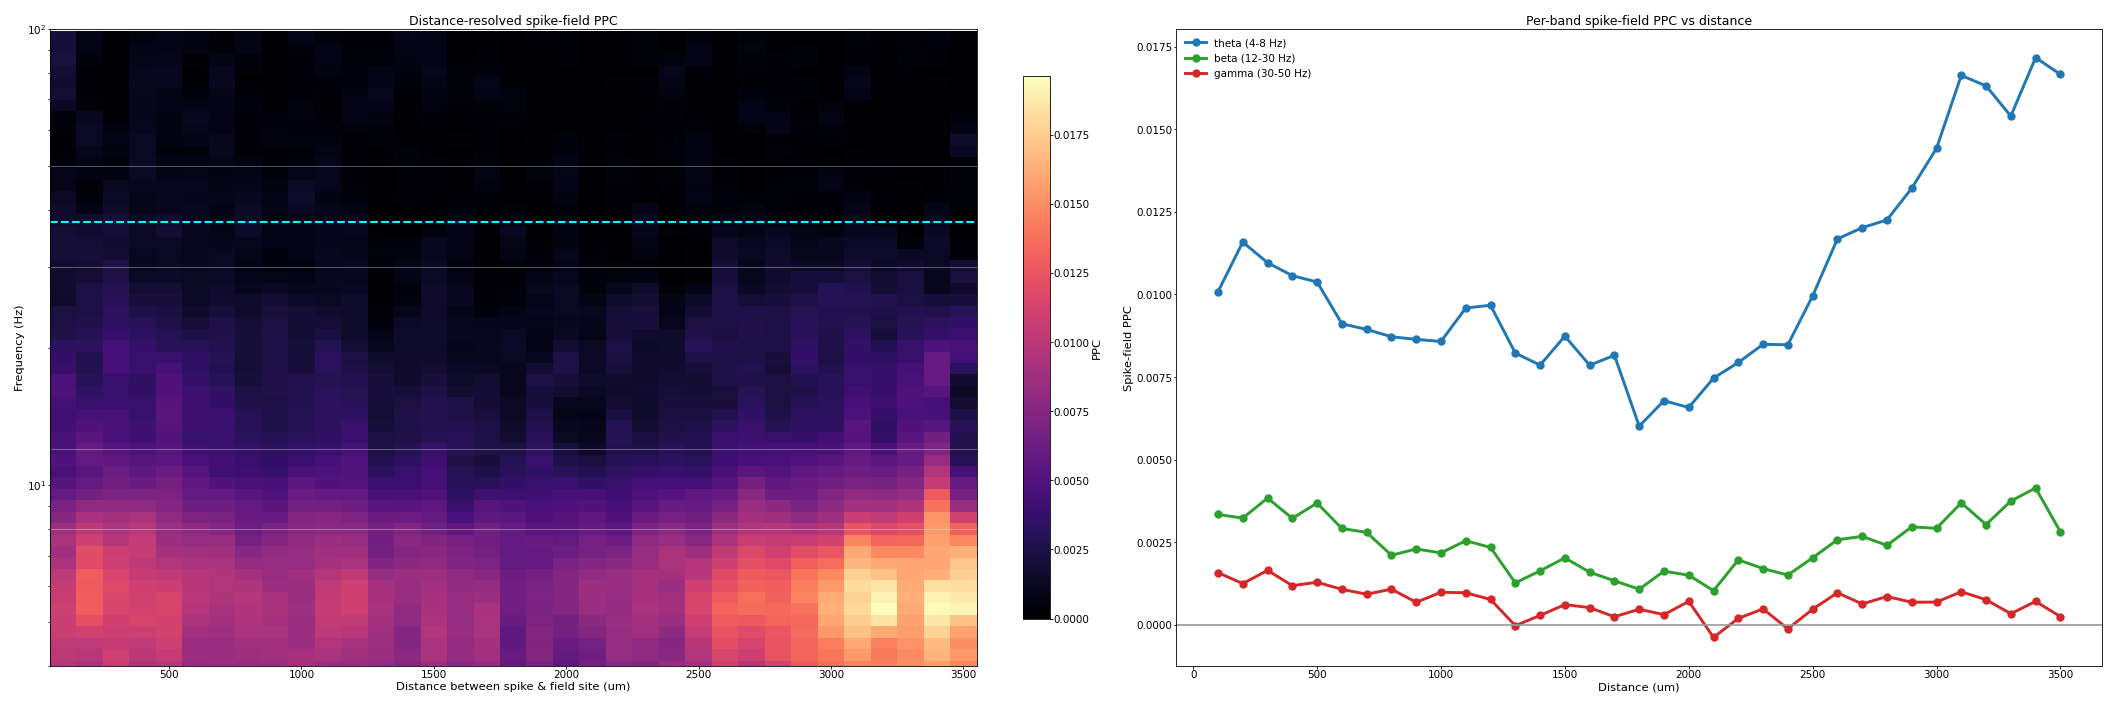

In [139]:
dr = spikefield.get("distance_resolved")
if dr is None or not np.any(np.isfinite(dr["ppc"])):
    print("No distance-resolved spike-field locking.")
else:
    dcen = dr["dist_centers_um"]; ff = dr["freq_hz"]; M = dr["ppc"]  # (n_dist, n_freq)
    keep = dr["n_pairs"] > 0
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True)
    im = axes[0].pcolormesh(dcen[keep], ff, M[keep].T, shading="auto", cmap="magma", vmin=0)
    axes[0].axhline(IFR_PEAK_HZ, color="cyan", lw=1.0, ls="--")
    for bnd in (8.0, 12.0, 30.0, 50.0):
        axes[0].axhline(bnd, color="white", lw=0.4, alpha=0.4)
    axes[0].set_yscale("log"); axes[0].set_ylim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
    axes[0].set(xlabel="Distance between spike & field site (um)", ylabel="Frequency (Hz)", title="Distance-resolved spike-field PPC")
    fig.colorbar(im, ax=axes[0], shrink=0.85, label="PPC")
    band_colors = {"theta": "tab:blue", "beta": "tab:green", "gamma": "tab:red"}
    for band, (lo, hi) in FREQUENCY_BANDS.items():
        bm = (ff >= lo) & (ff <= hi)
        axes[1].plot(dcen[keep], np.nanmean(M[keep][:, bm], axis=1), marker="o", ms=3, lw=1.4,
                     color=band_colors.get(band), label=f"{band} ({lo:g}-{hi:g} Hz)")
    axes[1].axhline(0.0, color="0.6", lw=0.8)
    axes[1].set(xlabel="Distance (um)", ylabel="Spike-field PPC", title="Per-band spike-field PPC vs distance")
    axes[1].legend(frameon=False)
    fig.savefig(FIGURE_DIR / "spike_field_locking_vs_distance.png", dpi=300, bbox_inches="tight")
    gm = (ff >= 30) & (ff <= 50)
    print(f"gamma PPC vs distance: max={np.nanmax(np.nanmean(M[keep][:, gm], axis=1)):.3f} at {dcen[keep][int(np.nanargmax(np.nanmean(M[keep][:, gm], axis=1)))]:.0f} um")

### Figure-3-style Rayleigh R per suboctave + circular distributions

Replicates figure 3's spike-phase methodology (same-electrode Hilbert/Morlet phase at spike times,
Rayleigh resultant R = |mean exp(i*phi)| pooled per well) but per Morlet suboctave instead of one
30-50 Hz band. `local` = figure-3 method (bleed-prone); `removed` = same with the spike waveform
blanked from the raw first. Comparing the two R(f) curves and the circular distributions shows which
suboctave the R is driven by and whether it survives spike removal.

local: Rayleigh R peak at 95.9 Hz (R=0.380); R@38Hz=0.128
removed: Rayleigh R peak at 85.4 Hz (R=0.108); R@38Hz=0.051


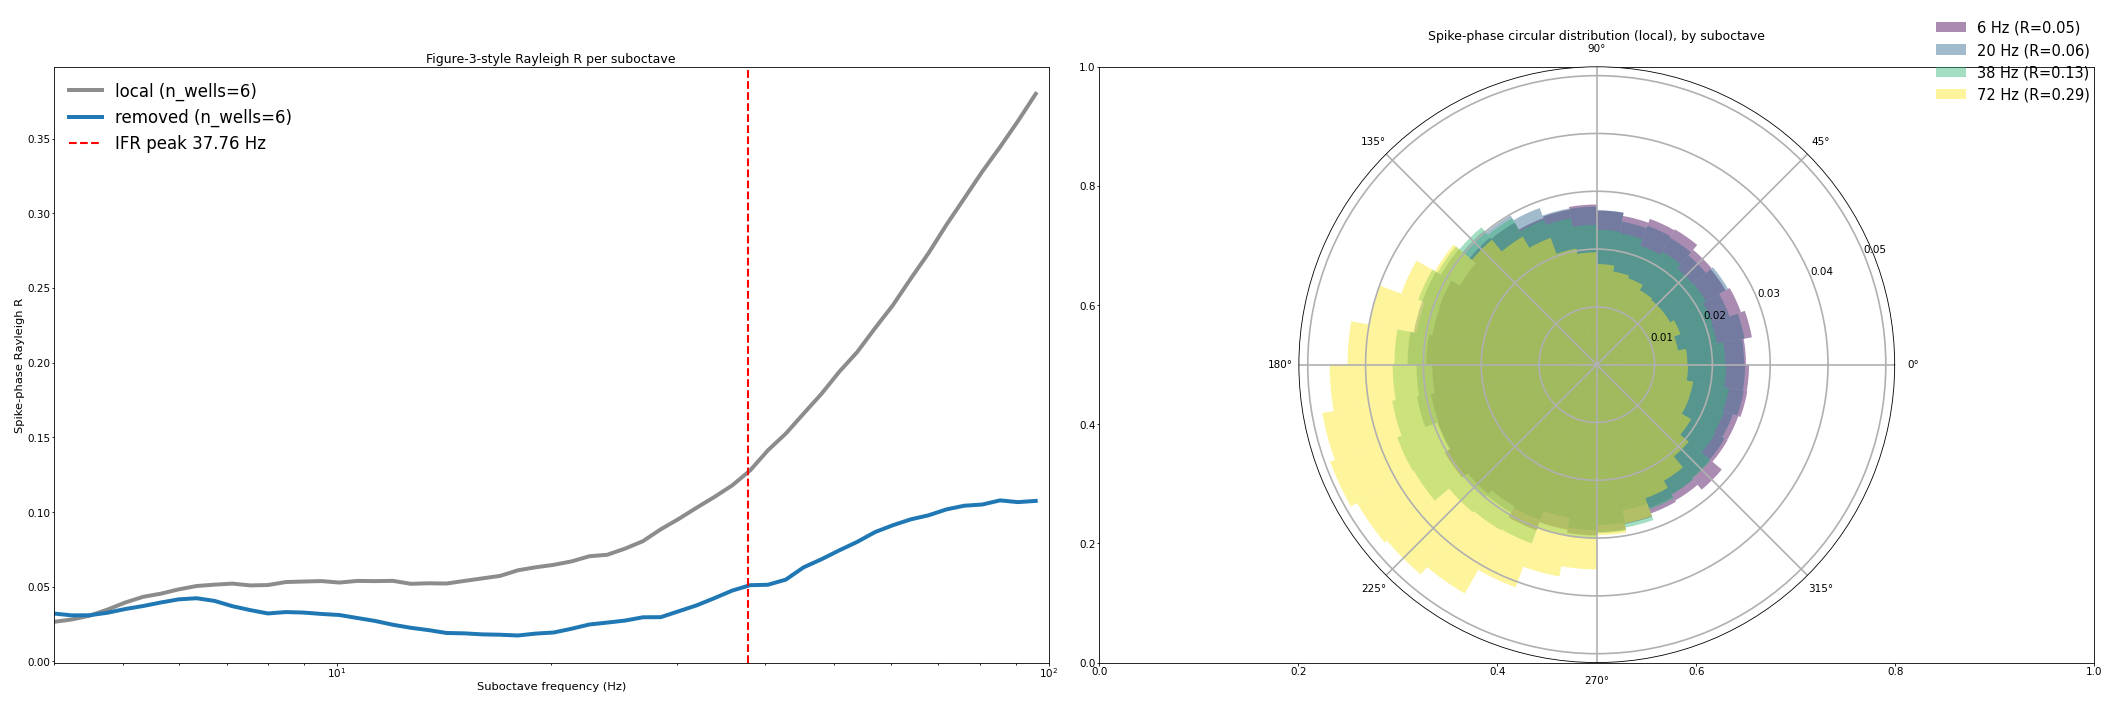

In [140]:
pc = spikefield["phase_centers"]
fR = spikefield["freq_hz"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True)
for m, col in (("local", "0.55"), ("removed", "tab:blue")):
    R = spikefield[m].get("rayleigh_R")
    if R is None or not np.any(np.isfinite(R)):
        continue
    axes[0].plot(fR, R, color=col, lw=1.9, label=f"{m} (n_wells={spikefield[m].get('rayleigh_n_wells', 0)})")
    pk = fR[int(np.nanargmax(R))]
    print(f"{m}: Rayleigh R peak at {pk:.1f} Hz (R={np.nanmax(R):.3f}); R@38Hz={R[int(np.argmin(np.abs(fR-IFR_PEAK_HZ)))]:.3f}")
axes[0].axvline(IFR_PEAK_HZ, color="red", lw=1.0, ls="--", label=f"IFR peak {IFR_PEAK_HZ:g} Hz")
axes[0].set_xscale("log"); axes[0].set_xlim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
axes[0].set(xlabel="Suboctave frequency (Hz)", ylabel="Spike-phase Rayleigh R", title="Figure-3-style Rayleigh R per suboctave")
axes[0].legend(frameon=False, fontsize=8)

# circular distributions at representative suboctaves
targets = [6.0, 20.0, IFR_PEAK_HZ, 70.0]
ax = plt.subplot(1, 2, 2, projection="polar")
cmap = plt.get_cmap("viridis")
width = (pc[1] - pc[0]) if pc.size > 1 else 0.2
for i, tf in enumerate(targets):
    fi = int(np.argmin(np.abs(fR - tf)))
    h = spikefield["local"]["phase_hist"][fi]
    if h.sum() <= 0:
        continue
    dens = h / h.sum()
    color = cmap(i / max(1, len(targets) - 1))
    ax.bar(pc, dens, width=width, bottom=0.0, color=color, alpha=0.45,
           label=f"{fR[fi]:.0f} Hz (R={spikefield['local']['rayleigh_R'][fi]:.2f})")
ax.set_title("Spike-phase circular distribution (local), by suboctave")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), frameon=False, fontsize=7)
fig.savefig(FIGURE_DIR / "spike_phase_rayleigh_suboctave.png", dpi=300, bbox_inches="tight")

## Step 10 - Validation checks

In [141]:
checks = {
    "anchors_nonempty": len(anchor_table) > 0,
    "lfp_anchors_inside_bursts": bool(anchor_table["lfp_anchor_inside_burst"].all()) if len(anchor_table) else False,
    "snap_offset_median_ms": float(np.nanmedian(anchor_table["anchor_offset_ms"])) if len(anchor_table) else float("nan"),
    "events_nonempty": len(selected_events) > 0,
    "distance_rows_nonempty": len(event_distance_coherence) > 0,
    "has_burst_and_shifted": bool({"burst", "shifted"}.issubset(set(event_distance_coherence.get("condition", pd.Series(dtype=str)).unique()))) if len(event_distance_coherence) else False,
}
checks

{'anchors_nonempty': True,
 'lfp_anchors_inside_bursts': True,
 'snap_offset_median_ms': -3.4999999999740794,
 'events_nonempty': True,
 'distance_rows_nonempty': True,
 'has_burst_and_shifted': True}